# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC; width: 100%;"><b>🏃 [Competiton : Predict Calorie Expenditure](https://www.kaggle.com/competitions/playground-series-s5e5/)</b></div>

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC; width: 100%;"><b></b>✨🚀📖Introduction</div>

Throughout this notebook we dissect the 750 k × 9 training set and the 250 k × 8 test set from every angle.

| Section | What we do | Why it matters |
|---------|------------|----------------|
| 1‑3     | Load libraries & glimpse raw tables| Sanity check shapes and dtypes |
| 4       | Missing‑value audit | Confirm data hygiene (spoiler: it’s perfect) |
| 5       | Target (`Calories`) deep dive | Pick the right loss transformation |
| 6‑7     | Univariate numeric & categorical plots | Detect skew, outliers, class balance |
| 8‑10    | Correlations, bivariate scatter & interactions | Reveal linear / non‑linear drivers |
| 11‑12   | Outlier count & multicollinearity (VIF) | Decide on cleaning and feature pruning |
| 13      | PCA preview | Gauge underlying dimensionality |
| 14      | Train‑vs‑test comparability | Verify no covariate shift |

At the end we summarise the **seven key insights** and sketch a data‑driven modelling roadmap.

Join the discussion [here](https://www.kaggle.com/competitions/playground-series-s5e5/)

---

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Executive Summary</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Summary</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </div>

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC; width: 100%;"><b></b>01 :🧰 Importing Libraries</div>

In [1]:
# Table Manipulation, CalculatinTg
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 100) # increase the maximum number of columns

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import missingno as msno
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Ignore all warnings
import warnings
warnings.simplefilter("ignore")

# Set seed for reproducibility
np.random.seed(42)

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC; width: 100%;"><b></b>02 :📥 Importing Datasets</div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ 1 : "df_train" has 750,000 rows × 9 columns, 90.12 MB which is a small-sized dataset.<br>
    └ 2 : "df_test" has 250,000 rows × 9 columns, 28.13 MB which is also a small-sized dataset.

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : Both "df_train" and "df_test" may sample when doing EDA such as Kmeans.
  </div>

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Tips : Data Scale Determination</strong>
  </h5>
    └ The following numerical ranges are used to determine data scale (primarily refer to byte size).<br>
    &emsp;└ Small Scale:<br>
    &emsp;&emsp;└ Data Points (Records × Columns): 1,000 to 999,999<br>
    &emsp;&emsp;└ Byte Size: 10 KB to 999 MB<br>
    &emsp;&emsp;└ Characteristics: Easily fits into Excel, a single RDBMS table, or a Pandas DataFrame. You can process it effortlessly using a typical PC's memory.<br>
    <br>
    &emsp;└ Medium Scale:<br>
    &emsp;&emsp;└ Data Points (Records × Columns): 1,000,000 to 999,999,999<br>
    &emsp;&emsp;└ Byte Size: 1 GB to 999 GB<br>
    &emsp;&emsp;└ Characteristics: Handling it with tools like Pandas might require a little care, but it generally fits within the memory of a single high-performance PC or server.<br>
    &emsp;&emsp;&emsp;However, complex analyses or machine learning model training might start to take a significant amount of time.<br>
<br>
    &emsp;└ Large Scale:<br>
    &emsp;&emsp;└ Data Points (Records × Columns): 1,000,000,000 to 99,999,999,999<br>
    &emsp;&emsp;└ Byte Size: 1 TB to 999 TB<br>
    &emsp;&emsp;└ Characteristics: This scale of data no longer fits into a single computer's memory.<br>
    &emsp;&emsp;&emsp;It necessitates the use of distributed processing frameworks (like Apache Spark, Hadoop) or cloud-based data warehouses/data lakes (such as BigQuery, Snowflake, Amazon S3).<br>
    <br>
    &emsp;└ Extra Large Scale (or Big Data):<br>
    &emsp;&emsp;└ Data Points (Records × Columns): 100,000,000,000 or more<br>
    &emsp;&emsp;└ Byte Size: 1 PB or more<br>
    &emsp;&emsp;└ Characteristics: This is the realm commonly referred to as "Big Data.<br>
    &emsp;&emsp;&emsp;" Due to its immense size, advanced distributed systems and specialized data engineering are indispensable for all aspects of data collection, storage, processing, and analysis.<br>
    &emsp;&emsp;&emsp;The velocity and variety of the data also become crucial factors.
<br>
</div>

In [2]:
df_train = pd.read_csv('/kaggle/input/playground-series-s5e5/train.csv') # importing 'train' data
df_test = pd.read_csv('/kaggle/input/playground-series-s5e5/test.csv')   # importing 'test' data

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Column list:</strong> 
  </h5>
    <strong>└ id</strong> : Identification number.<br>
    <strong>└ Age</strong> : The biological sex of the individual.<br>
    <strong>└ Height</strong> : The height of the individual.<br>
    <strong>└ Weight</strong> : The weight of the individual.<br>
    <strong>└ Duration</strong> : The length of the physical activity being recorded.<br>
    <strong>└ Heart_Rate</strong> : The number of times the heart beats per minute during the activity.<br>
    <strong>└ Body_Temp</strong> : The body temperature of the individual.<br>
    <strong>└ Calories</strong> : The number of calories burned by the individual during the recorded physical activity.
</div>

In [3]:
total_memory_bytes = df_train.memory_usage(deep=True).sum()
print(f"Total memory usage for the entire DataFrame: {total_memory_bytes} byte")
print(f"Total memory usage for the entire DataFrame: {total_memory_bytes / (1024**2):.2f} MB") # megabyte display
print(f"Total memory usage for the entire DataFrame: {total_memory_bytes / (1024**3):.2f} GB")  # Gigabyte display
display(df_train.info(memory_usage='deep'))

# 'train' data
display(df_train)

Total memory usage for the entire DataFrame: 94501574 byte
Total memory usage for the entire DataFrame: 90.12 MB
Total memory usage for the entire DataFrame: 0.09 GB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 90.1 MB


None

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
749995,749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0


In [4]:
total_memory_bytes = df_test.memory_usage(deep=True).sum()
print(f"Total memory usage for the entire DataFrame: {total_memory_bytes} byte")
print(f"Total memory usage for the entire DataFrame: {total_memory_bytes / (1024**2):.2f} MB") # megabyte display
print(f"Total memory usage for the entire DataFrame: {total_memory_bytes / (1024**3):.2f} GB")  # Gigabyte display
display(df_test.info(memory_usage='deep'))

# 'test' data
display(df_test)

Total memory usage for the entire DataFrame: 29500694 byte
Total memory usage for the entire DataFrame: 28.13 MB
Total memory usage for the entire DataFrame: 0.03 GB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   Sex         250000 non-null  object 
 2   Age         250000 non-null  int64  
 3   Height      250000 non-null  float64
 4   Weight      250000 non-null  float64
 5   Duration    250000 non-null  float64
 6   Heart_Rate  250000 non-null  float64
 7   Body_Temp   250000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 28.1 MB


None

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5
...,...,...,...,...,...,...,...,...
249995,999995,female,56,159.0,62.0,6.0,85.0,39.4
249996,999996,male,32,202.0,101.0,3.0,84.0,38.4
249997,999997,female,31,164.0,64.0,14.0,98.0,40.1
249998,999998,female,62,158.0,61.0,25.0,106.0,40.7


# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>📊🔍 EDA</b>

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>03 :🔬🧐 Data Inspection</b>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ 1 : Both "df_train" and "df_test" contain numeric data.

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : We will examine the details from this section onwards.
  </div>

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Tips : What is "Data Inspection"</strong>
  </h5>
    └ "Data Inspection" is a critical early step in the data analysis process and aims to understand
      the quality, integrity, structure and basic content of the data.<br>
      Simply put, it is the process of checking "what state the data is in and whether it is in a condition to be used properly.
</div>

In [5]:
# Check if each column has a unique value of 0 and 1, and assign 1 or 0
def check_if_binary(column):
    unique_values = column.unique()
    if len(unique_values) == 2 and set(unique_values) == {0, 1}:
        return 1
    else:
        return 0

In [6]:
def check_if_outliers(df):

    outliers_rate_dict = {}

    for column_name in df.columns:
        column = df[column_name]

        # Skip if not a numeric column
        if not pd.api.types.is_numeric_dtype(column):
            print(f"'{column_name}' is skipped because it is not a numeric type.")
            continue

        # Calculate the mean and standard deviation of the data
        mean = column.mean()
        std = column.std()

        # Set outlier threshold
        threshold = 2  # Adjust this value to change the outlier criteria

        # Set conditions for detecting outliers
        lower_bound = mean - threshold * std
        upper_bound = mean + threshold * std

        # Detect outliers
        outliers = (column < lower_bound) | (column > upper_bound)

        # Calculate the percentage of outliers
        outliers_rate = outliers.sum() / len(column)

        # Save results to dictionary
        outliers_rate_dict[column_name] = outliers_rate

    return outliers_rate_dict

In [7]:
def data_inspection(df):
    """A function that generates data inspection information for a data frame"""

    # process_one:Create a DataFrame with basic statistics
    data_inspection = pd.DataFrame({
        'column_name'         : df.columns,
        'data_type'           : df.dtypes,
        'cnt_rows'            : len(df),
        'cnt_unique_rows'     : df.nunique(),
        'cnt_duplicated_rows' : len(df) - df.nunique(),
        'cnt_non_null_rows'   : df.count().values,
        'cnt_null_rows'       : df.isnull().sum(),
        'rate_null_rows'      : (df.isnull().sum() / len(df)),
    })

    # process_two:Calculate descriptive statistics, modes, and percentages of modes for numerical data:
    
    # The below code is no longer needed as 'custom_description' provides the stats
    # description = df.describe(include=np.number).T.reset_index().rename(columns={'index': 'column_name'})
    # median = df.median(numeric_only=True).reset_index().rename(columns={'index': 'column_name', 0: 'median'})

    # Calculate the most frequent value for each column
    mode_values = {}
    for column in df.columns:
        try:
            mode_values[column] = df[column].mode().iloc[0]
        except IndexError:
            mode_values[column] = None  # Handle cases with no mode

    # Calculate the percentage of most frequent values
    mode_rates = {}
    for column in df.columns:
        if column in mode_values and mode_values[column] is not None:
            mode_value = mode_values[column]
            mode_rate = (df[column] == mode_value).sum() / len(df)
            mode_rates[column] = mode_rate
        else:
            mode_rates[column] = None

    # Convert the most common value and its percentage into a data frame
    df_mode = pd.DataFrame(list(mode_values.items()), columns=['column_name', 'mode'])
    df_mode['rate mode'] = df_mode['column_name'].map(mode_rates)

    # Custom statistics calculation without using df.describe for basic stats
    def calculate_custom_stats(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        return pd.Series({
            'count': series.count(),
            'mean': series.mean(),
            'std': series.std(),
            # 'q1-1.5*QTR': q1 - 1.5 * iqr,
            '0%': series.quantile(0),
            '25%': q1,
            '50%': series.median(),
            '75%': q3,
            '100%': series.quantile(1),
            'lower_bound': series.mean() - 2 * series.std(),
            'upper_bound': series.mean() + 2 * series.std()
            # 'q3+1.5*QTR': q3 + 1.5 * iqr
        })

    df_numeric = df.select_dtypes(include=np.number)
    custom_description = df_numeric.apply(calculate_custom_stats).T.reset_index(names='column_name')

    # process_three:Combining DataFrames and adding outlier rates, skewness, and kurtosis:
    data_inspection = pd.merge(data_inspection, custom_description, how='left', on='column_name')
    data_inspection = pd.merge(data_inspection, df_mode, how='left', on='column_name')

    # # The 'description' merge is no longer needed as 'custom_description' provides the stats
    # data_inspection = pd.merge(data_inspection, description, how='left', on='column_name')

    outliers_rate = check_if_outliers(df)
    outliers_rate = pd.DataFrame(list(outliers_rate.items()), columns=['column_name', 'outliers_rate']).reset_index(drop=True)
    data_inspection = pd.merge(data_inspection, outliers_rate, how='left', on='column_name')

    # skewness and kurtosis
    skew = df.select_dtypes(include=np.number).skew().reset_index().rename(columns={'index': 'column_name', 0: 'skewness'})
    kurt = df.select_dtypes(include=np.number).kurt().reset_index().rename(columns={'index': 'column_name', 0: 'kurtosis'})

    data_inspection = pd.merge(data_inspection, skew, how='left', on='column_name')
    data_inspection = pd.merge(data_inspection, kurt, how='left', on='column_name')

    # Calculating correlation coefficients (numeric columns only)
    df_numeric = df.select_dtypes(include=np.number)
    if not df_numeric.empty and df_numeric.shape[1] > 1:
        try:
            correlation_matrix = df_numeric.corr(numeric_only=True)

            # Assuming the last column is the target variable for correlation
            target_column = df_numeric.columns[-1]
            if target_column in correlation_matrix.index:
                target_corr = pd.DataFrame({'column_name': correlation_matrix.index, 'target correlation': correlation_matrix[target_column]})
                data_inspection = pd.merge(data_inspection, target_corr, how='left', on='column_name')
            else:
                data_inspection['target correlation'] = np.nan
        except Exception as e:
            print(f"Error calculating correlation: {e}")
            data_inspection['target correlation'] = np.nan
    else:
        data_inspection['target correlation'] = np.nan

    # process_four:Adding more column information and example data
    data_inspection_else = pd.DataFrame({
        'column_name': df.columns,
        'flag_or_not': df.apply(check_if_binary),
        'columns_details': None,
        'remarks': None,
        'trigger': None,
        'dataset_name': None,
        'existence_of_table_definition': None,
        'data_exmaple': df.head(1).T.iloc[:, 0].astype(str).replace('\n', '<br>')
    })

    data_inspection = pd.merge(data_inspection, data_inspection_else, how='left', on='column_name')

    # visualization `data_inspection`
    # blue → green → yellow
    styled_columns = data_inspection.select_dtypes(include=np.number).columns
    if not styled_columns.empty:
        data_inspection_styled = data_inspection.style.background_gradient(cmap='viridis', subset=pd.IndexSlice[:, styled_columns])
    else:
        data_inspection_styled = data_inspection

    return data_inspection_styled

### <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>df_train</b>

In [8]:
df_train_tmp = df_train.drop('id', axis=1)
data_inspection_styled = data_inspection(df_train_tmp)
display(data_inspection_styled)
# data_inspection.to_csv('data_inspection.csv', index = 'false') # Saving the dataframe if necessary

'Sex' is skipped because it is not a numeric type.


,column_name,data_type,cnt_rows,cnt_unique_rows,cnt_duplicated_rows,cnt_non_null_rows,cnt_null_rows,rate_null_rows,count,mean,std,0%,25%,50%,75%,100%,lower_bound,upper_bound,mode,rate mode,outliers_rate,skewness,kurtosis,target correlation,flag_or_not,columns_details,remarks,trigger,dataset_name,existence_of_table_definition,data_exmaple
0,Sex,object,750000,2,749998,750000,0,0.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,female,0.500961,nan,nan,nan,nan,0,None,None,None,None,None,male
1,Age,int64,750000,60,749940,750000,0,0.000000,750000.000000,41.420404,15.175049,20.000000,28.000000,40.000000,52.000000,79.000000,11.070306,71.770502,21,0.048520,0.035976,0.436397,-0.746338,0.145683,0,None,None,None,None,None,36
2,Height,float64,750000,86,749914,750000,0,0.000000,750000.000000,174.697685,12.824496,126.000000,164.000000,174.000000,185.000000,222.000000,149.048694,200.346677,161.000000,0.035387,0.022101,0.051777,-0.839800,-0.004026,0,None,None,None,None,None,189.0
3,Weight,float64,750000,91,749909,750000,0,0.000000,750000.000000,75.145668,13.982704,36.000000,63.000000,74.000000,87.000000,132.000000,47.180261,103.111075,61.000000,0.037292,0.009600,0.211194,-0.996077,0.015863,0,None,None,None,None,None,82.0
4,Duration,float64,750000,30,749970,750000,0,0.000000,750000.000000,15.421015,8.354095,1.000000,8.000000,15.000000,23.000000,30.000000,-1.287176,32.129206,9.000000,0.038533,0.000000,0.026259,-1.195390,0.959908,0,None,None,None,None,None,26.0
5,Heart_Rate,float64,750000,63,749937,750000,0,0.000000,750000.000000,95.483995,9.449845,67.000000,88.000000,95.000000,103.000000,128.000000,76.584304,114.383685,91.000000,0.045844,0.026051,-0.005668,-0.676563,0.908748,0,None,None,None,None,None,101.0
6,Body_Temp,float64,750000,75,749925,750000,0,0.000000,750000.000000,40.036253,0.779875,37.100000,39.600000,40.300000,40.700000,41.500000,38.476504,41.596002,40.700000,0.089667,0.049905,-1.022361,0.519624,0.828671,0,None,None,None,None,None,41.0
7,Calories,float64,750000,277,749723,750000,0,0.000000,750000.000000,88.282781,62.395349,1.000000,34.000000,77.000000,136.000000,314.000000,-36.507917,213.073479,7.000000,0.011133,0.029272,0.539196,-0.689513,1.000000,0,None,None,None,None,None,150.0


### <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>df_test</b>

In [9]:
df_test_tmp = df_test.drop('id', axis=1)
data_inspection_styled = data_inspection(df_test_tmp)
display(data_inspection_styled)
# data_inspection.to_csv('data_inspection.csv', index = 'false')  # Saving the dataframe if necessary

'Sex' is skipped because it is not a numeric type.


,column_name,data_type,cnt_rows,cnt_unique_rows,cnt_duplicated_rows,cnt_non_null_rows,cnt_null_rows,rate_null_rows,count,mean,std,0%,25%,50%,75%,100%,lower_bound,upper_bound,mode,rate mode,outliers_rate,skewness,kurtosis,target correlation,flag_or_not,columns_details,remarks,trigger,dataset_name,existence_of_table_definition,data_exmaple
0,Sex,object,250000,2,249998,250000,0,0.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,female,0.501124,nan,nan,nan,nan,0,None,None,None,None,None,male
1,Age,int64,250000,60,249940,250000,0,0.000000,250000.000000,41.452464,15.177769,20.000000,28.000000,40.000000,52.000000,79.000000,11.096926,71.808002,21,0.048736,0.035920,0.434611,-0.749070,0.031114,0,None,None,None,None,None,45
2,Height,float64,250000,85,249915,250000,0,0.000000,250000.000000,174.725624,12.822039,127.000000,164.000000,174.000000,185.000000,219.000000,149.081546,200.369702,187.000000,0.035128,0.021656,0.043409,-0.843128,-0.033645,0,None,None,None,None,None,177.0
3,Weight,float64,250000,84,249916,250000,0,0.000000,250000.000000,75.147712,13.979513,39.000000,63.000000,74.000000,87.000000,126.000000,47.188687,103.106737,61.000000,0.037244,0.009288,0.207449,-1.002317,-0.023704,0,None,None,None,None,None,81.0
4,Duration,float64,250000,30,249970,250000,0,0.000000,250000.000000,15.415428,8.349133,1.000000,8.000000,15.000000,23.000000,30.000000,-1.282838,32.113694,9.000000,0.038488,0.000000,0.030302,-1.193598,0.902594,0,None,None,None,None,None,7.0
5,Heart_Rate,float64,250000,61,249939,250000,0,0.000000,250000.000000,95.479084,9.450161,67.000000,88.000000,95.000000,103.000000,128.000000,76.578763,114.379405,91.000000,0.046244,0.026084,-0.005194,-0.675792,0.794969,0,None,None,None,None,None,87.0
6,Body_Temp,float64,250000,51,249949,250000,0,0.000000,250000.000000,40.036093,0.778448,37.100000,39.600000,40.300000,40.600000,41.500000,38.479197,41.592988,40.700000,0.088524,0.049848,-1.021889,0.523997,1.000000,0,None,None,None,None,None,39.8


<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Tips : What is "Skewness" and "Kurtosis"</strong>
  </h5>
    └ The skewness and kurtosis measures provide important insight into how far the distribution of data deviates from normal distribution.<br>
    &emsp;└ Skewness : measures the "asymmetry" of a data distribution.<br>
    &emsp;└ Kurtosis : measures the "tailedness" of a data distribution.

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Regarding "Skewness"</strong>
  </h5>
    └ In cases where:<br>
    &emsp;└ the positive number is high (Positive Skewness) :<br>
    &emsp;&emsp;└ Shape of the distribution : Asymmetric with a peak to the left and a long tail to the right.<br>
    &emsp;└ the negative number is high (Negative Skewness) :<br>
    &emsp;&emsp;└ Shape of the distribution : Asymmetric with a peak to the right and a long tail on the left.<br>    
    &emsp;└ the number is zero (Zero Skewness):<br>
    &emsp;&emsp;└ Shape of distribution: Nearly symmetric.<br>
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Regarding "Kurtosis"</strong>
  </h5>
    └ In cases where:<br>
    &emsp;└ the positive number is high (Positive Kurtosis, Leptokurtic) :<br>
    &emsp;&emsp;└ Shape of the distribution : The peak is sharper than a normal distribution and the tails are thicker.<br>
    &emsp;└ the negative number is high (Negative Kurtosis, Platykurtic) :<br>
    &emsp;&emsp;└ Shape of the distribution : The peak is flatter and has thinner tails than a normal distribution.<br>
    &emsp;└ the number is zero (Zero Kurtosis, Mesokurtic):<br>
    &emsp;&emsp;└ Shape of distribution: It is bell-shaped with moderate peaking and heavy tails, roughly equivalent to a normal distribution.<br>
</div>

</div>

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>04 :🩹🗑️ Missing Values Analysis</b></div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ 1 : Both "df_train" and "df_test" have no missing values in their columns.

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : We don't need to perform preprocessing for "df_train" and "df_test", like missing value imputation.
  </div>

In [10]:
def create_missing_value_plots(df: pd.DataFrame):
    """
    It generates four types of plots (Matrix, Bar, Heatmap, Dendrogram) to visualize missing values ​​in a data frame.

    Args:
        df (pd.DataFrame): The DataFrame to perform missing value analysis on.
    """
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

    # Missing Value Matrix
    msno.matrix(df, sparkline=True, ax=axes[0, 0], color=(0.2, 0.2, 0.2))
    axes[0, 0].set_title("Missing Value Matrix")

    # Missing Value Bar Plot
    msno.bar(df, ax=axes[0, 1], color='skyblue')
    axes[0, 1].set_title("Missing Value Bar Plot")

    # Missing Value Correlation Heatmap
    msno.heatmap(df, ax=axes[1, 0], cmap='viridis')
    axes[1, 0].set_title("Missing Value Correlation Heatmap")

    # Missing Value Dendrogram
    msno.dendrogram(df, ax=axes[1, 1])
    axes[1, 1].set_title("Missing Value Dendrogram")

    # Adjusting the layout
    plt.tight_layout()
    plt.show()

### <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>df_train</b>

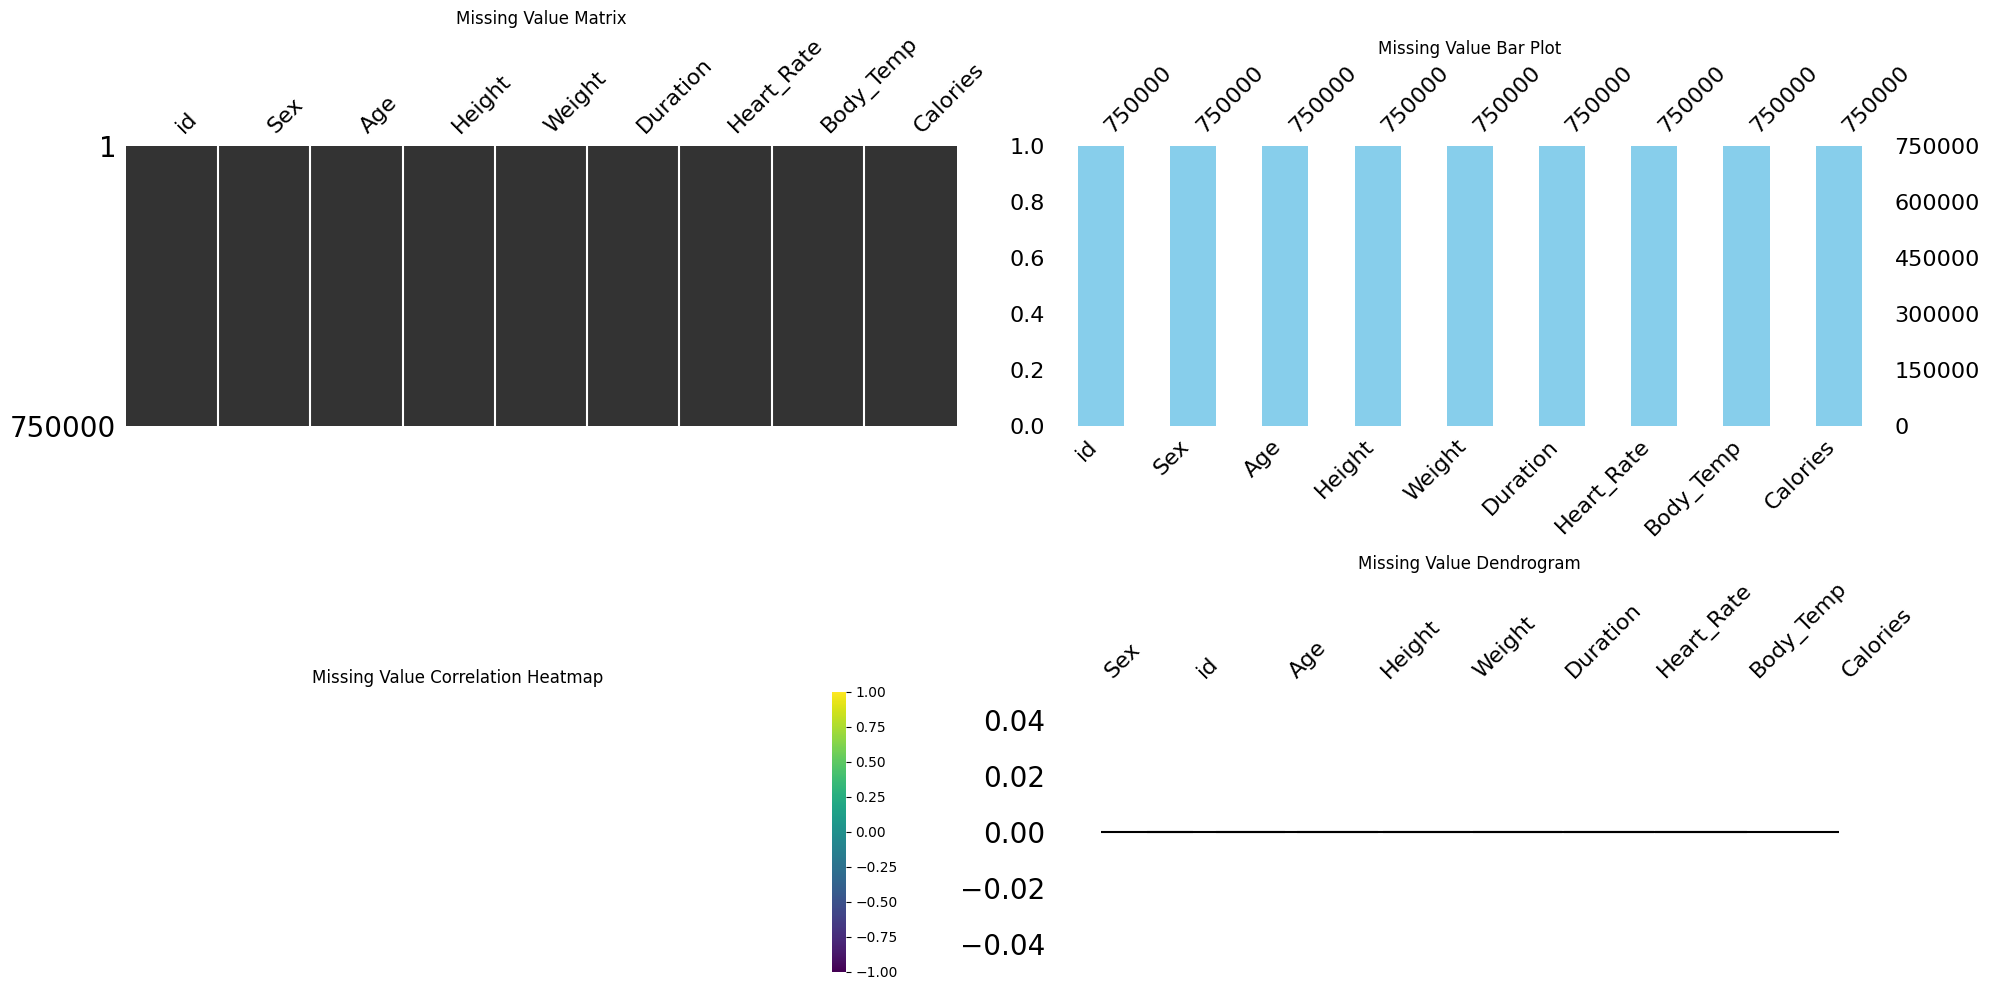

In [11]:
# df_train
create_missing_value_plots(df_train)

### <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>df_test</b>

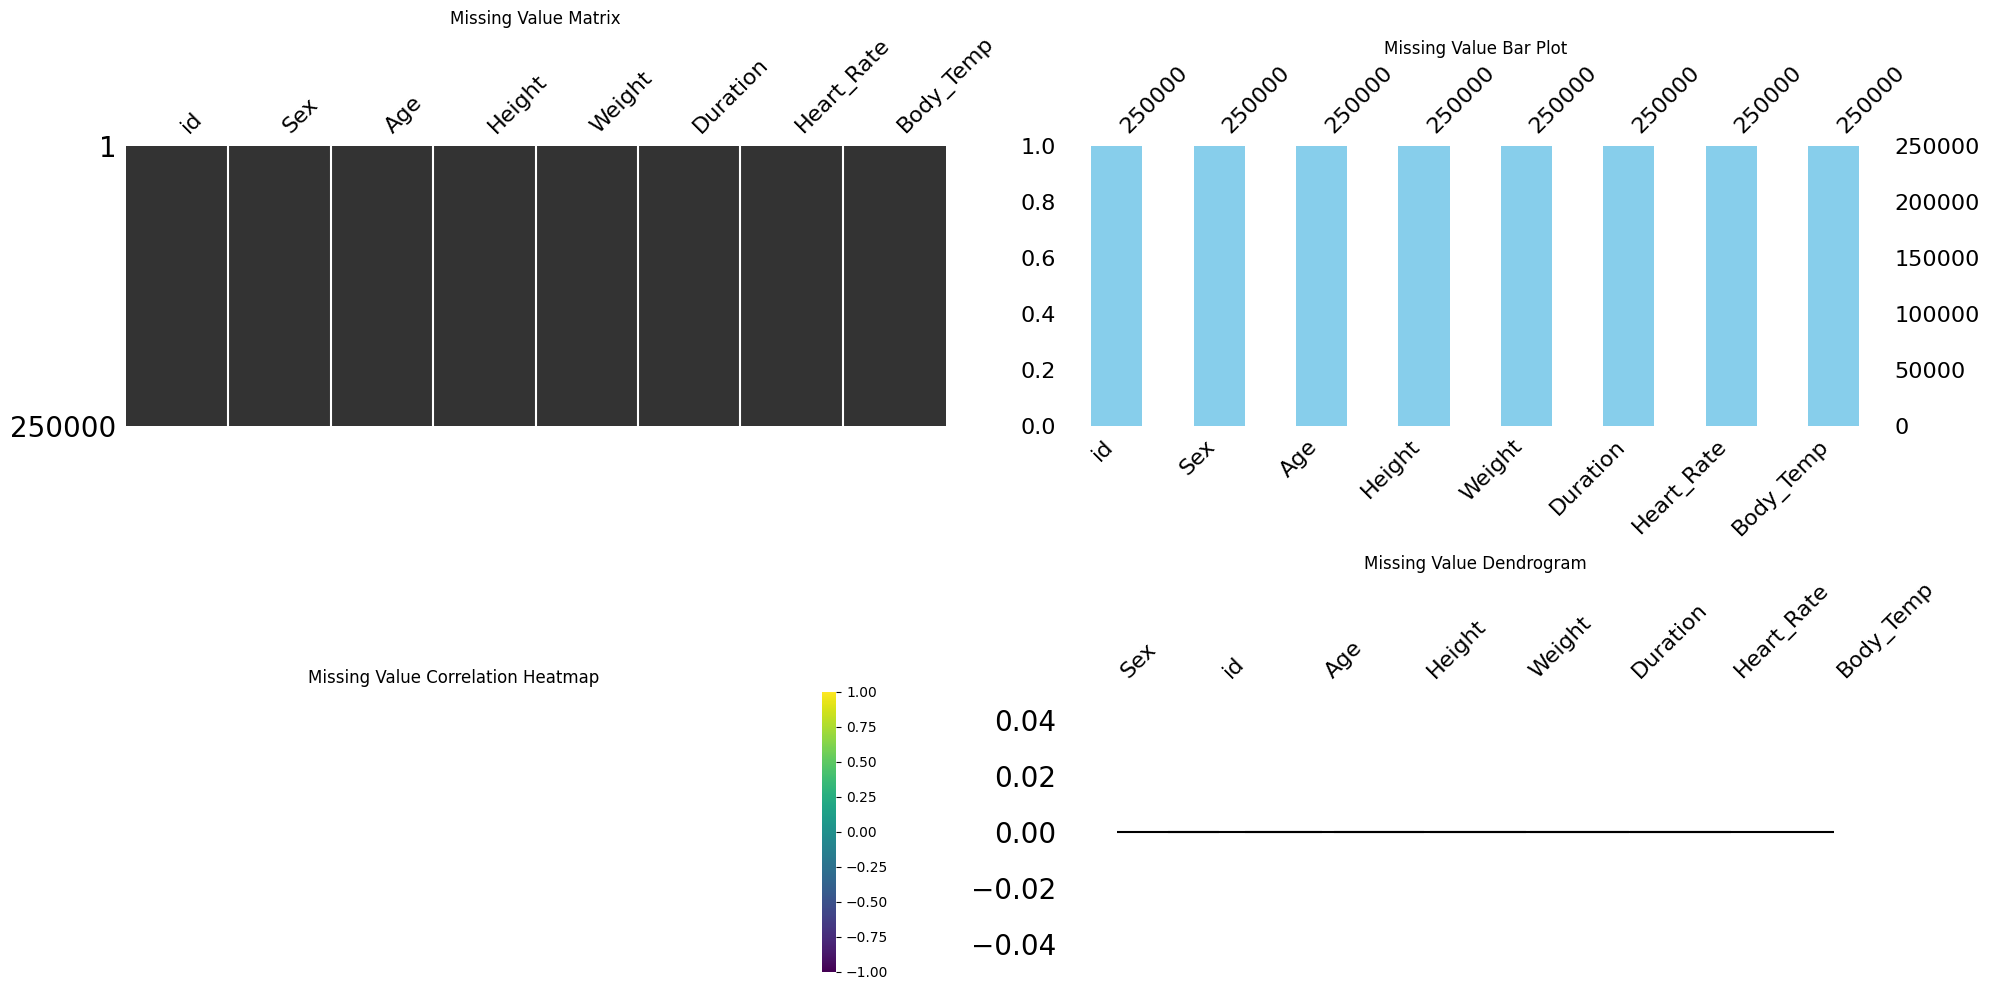

In [12]:
# df_test
create_missing_value_plots(df_test)

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>05 :📦📈 Univariate Analysis</b></div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ Numerical Variables:<br>
    &emsp;└ Box plot:<br>
    &emsp;&emsp;└ Both "df_train" and "df_test" have no obvious outliers.<br>
    &emsp;└ Histogram:<br>
    &emsp;&emsp;└ The distributions of both "df_train" and "df_test" are similarv.<br>
    └ Categorical Variables:<br>
    &emsp;└ Pie chart and count plot:<br>
    &emsp;&emsp;└ The ratios of categories in both "df_train" and "df_test" are roughly equal.<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : We don"t need to perform preprocessing for "df_train" and "df_test", such as clipping.
  </div>

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Tips : How to determine probability distribution</strong>
  </h5>
    └ Skewness and kurtosis values, along with graphs such as histograms and KDE curves, provide a very powerful perspective for roughly understanding the characteristics of the data's probability distribution and identifying what type of probability distribution best fits it<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Interpreting Skewness, Kurtosis, and Histograms</strong>
      </h5>
    &emsp;└ Skewness<br>
     &emsp;&emsp;└ Skewness value near 0: Suggests distributions like Normal, t, Logistic, or Uniform distributions.<br>
     &emsp;&emsp;└ Skewness value highly positive: Suggests distributions like Exponential, Log-Normal, Gamma, or Chi-squared distributions.<br>
     &emsp;&emsp;└ Skewness value highly negative: Suggests distributions like Beta or Weibull distributions.<br>
    <br>
    &emsp;└ Kurtosis<br>
     &emsp;&emsp;└ Kurtosis value near 0: Suggests a Normal distribution (mesokurtic).<br>
     &emsp;&emsp;└ Kurtosis value highly positive: Suggests distributions like t, Laplace, or Cauchy distributions (leptokurtic).<br>
     &emsp;&emsp;└ Kurtosis value highly negative: Suggests Uniform or Beta distributions (platykurtic).<br>
    <br>
    &emsp;└ Graphs (Histograms / KDE Curves)<br>
     &emsp;&emsp;└ Unimodal distribution: Indicates that the data comes from a single population.<br>
     &emsp;&emsp;└ Bimodal or multimodal distribution: Suggests that multiple distinct populations are mixed within the data (a mixture distribution).

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Additional Considerations for Distribution Assessment</strong>
  </h5>
    └ To make more accurate judgments about a data's probability distribution, consider these supplementary points:<br>
    &emsp;└ Sample Size:<br>
    &emsp;&emsp;└ Skewness and kurtosis values can be unstable with small sample sizes. <br>
    &emsp;&emsp;Larger sample sizes generally lead to these statistics more accurately reflecting the true underlying distribution.<br>
    <br>
    &emsp;└ Outliers:<br>
    &emsp;&emsp;└ Outliers can significantly impact skewness and kurtosis values. <br>
    &emsp;&emsp;It's crucial to consider the presence of outliers and their potential influence on your distribution assessment.<br>
    <br>
    &emsp;└ Domain Knowledge:<br>
    &emsp;&emsp;└ Understanding the phenomena or processes behind your data (i.e., domain knowledge) is extremely valuable for determining the appropriate probability distribution. <br>
    &emsp;&emsp;For instance, measurement errors often tend to follow a normal distribution, while waiting times might follow an exponential distribution.<br>
    <br>
    &emsp;└ Goodness-of-Fit Tests:<br>
    &emsp;&emsp;└ Visual inspections using skewness, kurtosis, and graphs provide only an initial screening. <br>
    &emsp;&emsp;To quantitatively evaluate how well a specific distribution fits your data, it's common to use Goodness-of-Fit Tests (e.g., Kolmogorov-Smirnov test, Shapiro-Wilk test, Chi-squared test).
</div>

</div>

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Regarding probability distribution</strong>
  </h5>
    └ Each column may exhibit the following probability distribution characteristics:<br>
    &emsp;└ Age : Lognormal Distribution, Gamma Distribution, Weibull Distribution (can be Mixture Distribution)<br>
    &emsp;└ Height : Mixture of Normal Distributions, Normal Distribution<br>
    &emsp;└ Weight : Mixture of Normal Distributions, Normal Distribution<br>
    &emsp;└ Duration : Uniform Distribution<br>
    &emsp;└ Heart_Rate : Mixture of Normal Distributions, Normal Distribution<br>
    &emsp;└ Body_Temp : Beta Distribution, Truncated Normal Distribution<br>
    &emsp;└ Calories : Exponential Distribution, Gamma Distribution, Weibull Distribution, Lognormal Distribution<br>
</div>

In [13]:
# A function to create plots for each variable
def create_variable_plots(variable, data_type='numerical'):

    sns.set_style('whitegrid')

    # For numeric data
    if data_type == 'numerical':
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))

        # Box plot
        plt.subplot(1, 2, 1)
        sns.boxplot(data=pd.concat([df_train, df_test]), x=variable, y="dataset", palette=custom_palette)
        plt.xlabel(variable)
        plt.title(f"Box plot for {variable}")

        # histgram
        plt.subplot(1, 2, 2)
        sns.histplot(data=df_train, x=variable, color=custom_palette[0], kde=True, bins=30, label="train")
        if variable in df_test.columns:
            sns.histplot(data=df_test, x=variable, color=custom_palette[1], kde=True, bins=30, label="test")

        plt.xlabel(variable)
        plt.ylabel("Frequency")
        plt.title(f"Histogram for {variable} [train & test]" if variable in df_test.columns else f"Histogram for {variable} [train]")
        plt.legend()

    # For categorical data
    elif data_type == 'categorical':
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # pie chart for train data
        plt.subplot(1, 2, 1)
        train_counts = df_train[variable].value_counts(normalize=True)
        train_counts.plot(kind='pie', autopct='%1.1f%%', colors=[custom_palette[0]] * len(train_counts), startangle=90, ax=plt.gca())
        plt.title(f"Pie chart for {variable} [train]")
        plt.tight_layout()

        # pie chart for test data
        plt.subplot(1, 2, 2)
        if variable in df_test.columns:
            test_counts = df_test[variable].value_counts(normalize=True)
            test_counts.plot(kind='pie', autopct='%1.1f%%', colors=[custom_palette[1]] * len(test_counts), startangle=90, ax=plt.gca())
            plt.title(f"Pie chart for {variable} [test]")
        else:
            plt.gca().axis('off') # Empty plot if no columns in test data

        # countplot
        fig_countplot, ax_countplot = plt.subplots(figsize=(15, 6))
        sns.countplot(data=df_train, x=variable, color=custom_palette[0], alpha=0.7, label="train", ax=ax_countplot)
        if variable in df_test.columns:
            sns.countplot(data=df_test, x=variable, color=custom_palette[1], alpha=0.7, label="test", ax=ax_countplot)
        ax_countplot.set_title(f"Count plot for {variable} [train & test]")
        ax_countplot.legend()
        plt.tight_layout()
        plt.show()

    plt.tight_layout()
    plt.show()

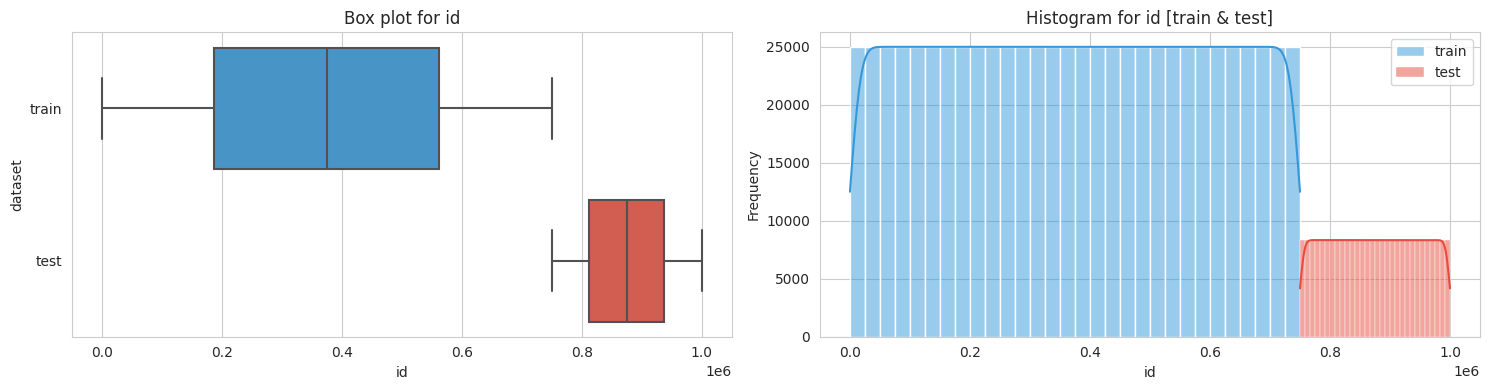

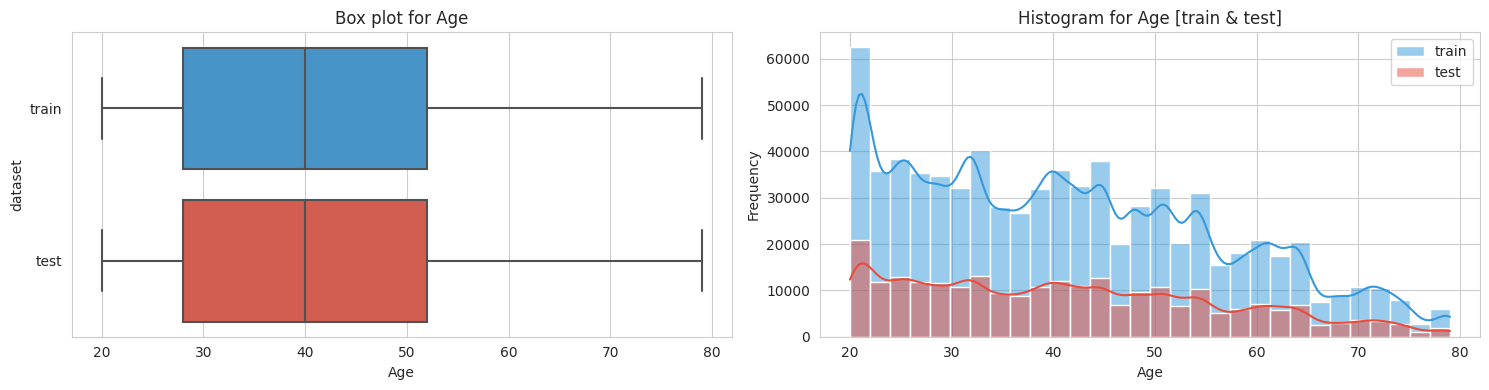

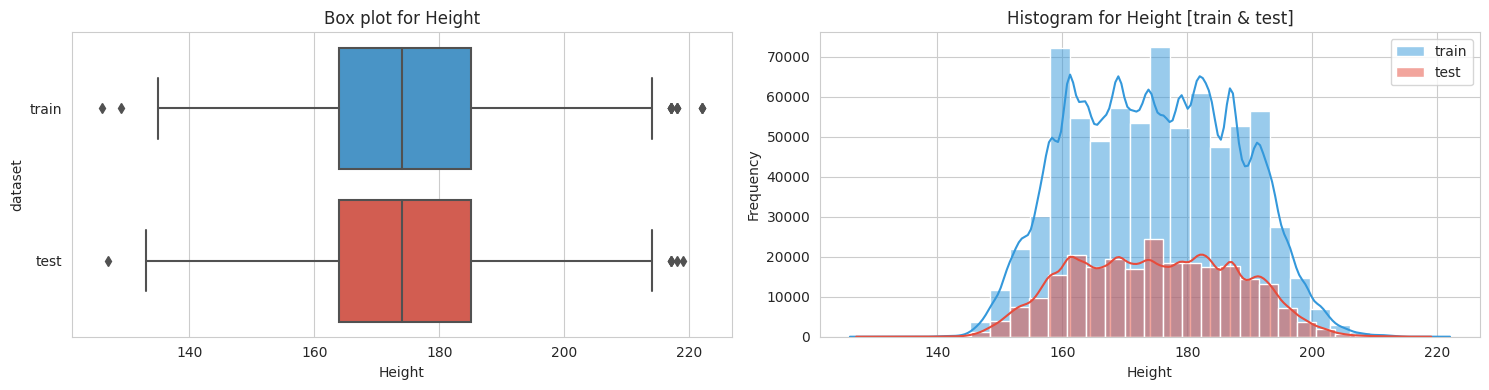

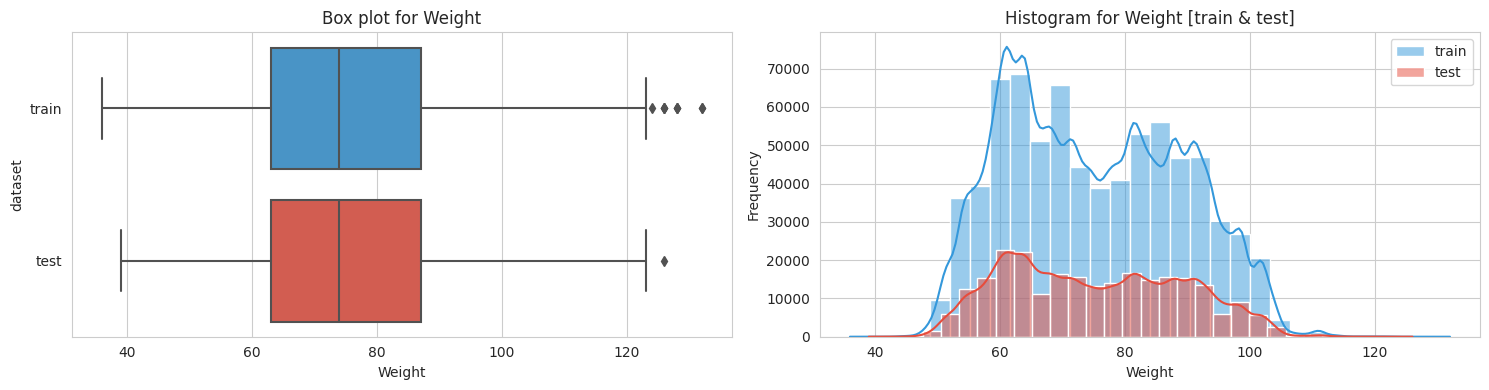

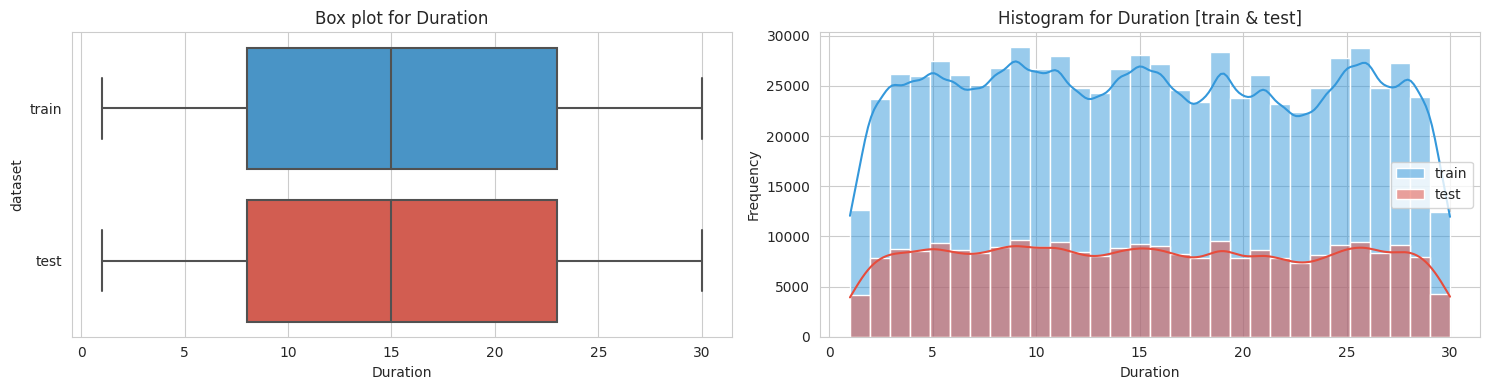

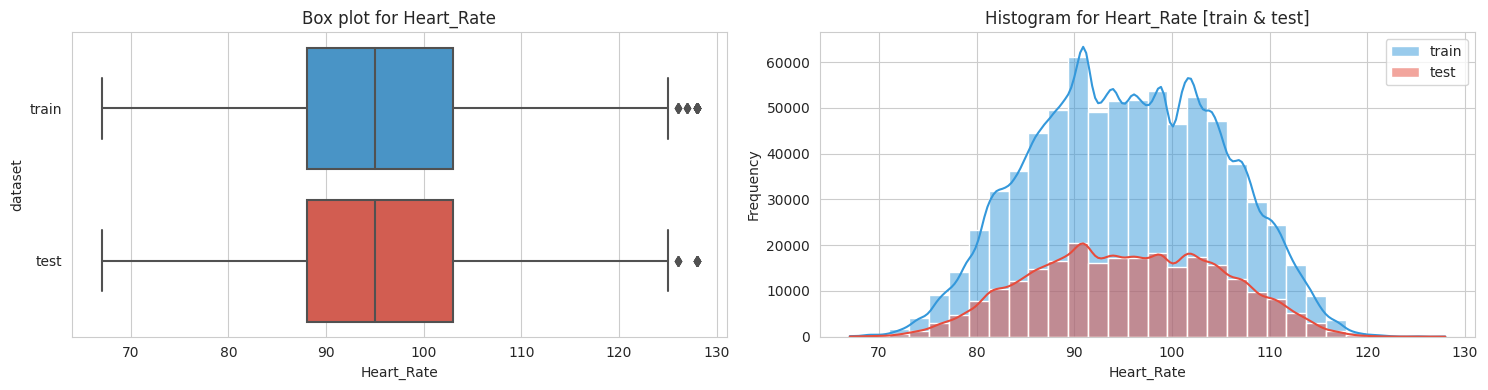

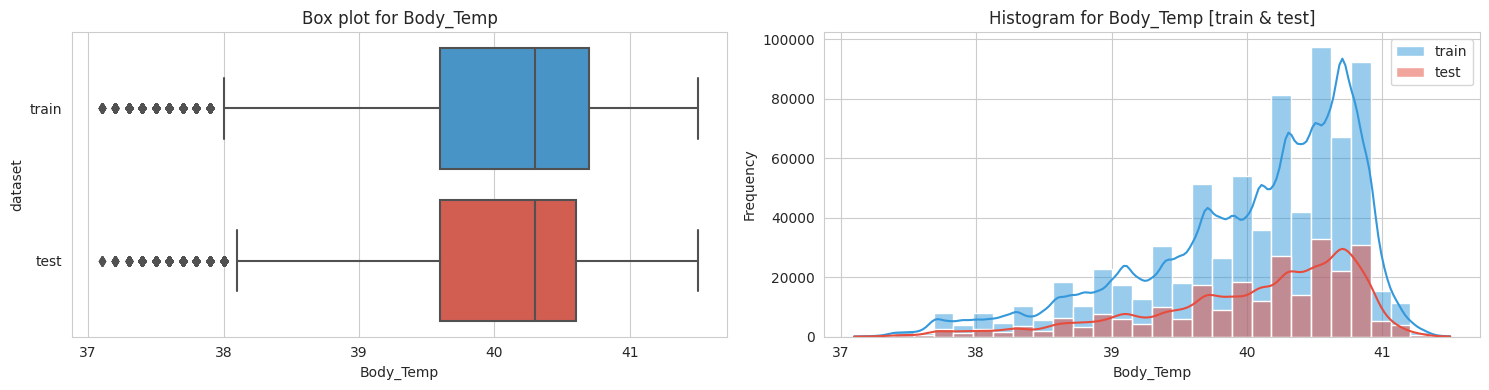

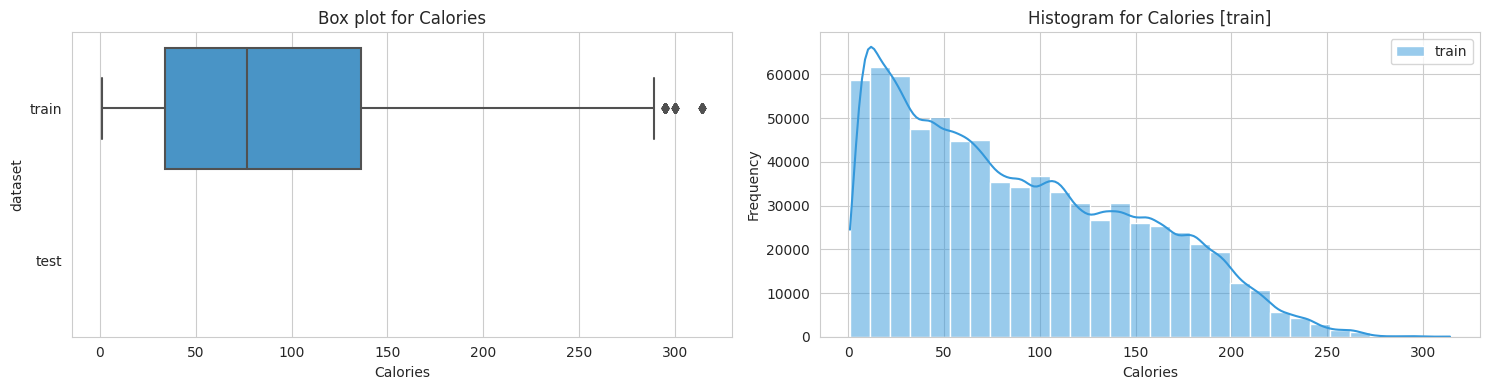

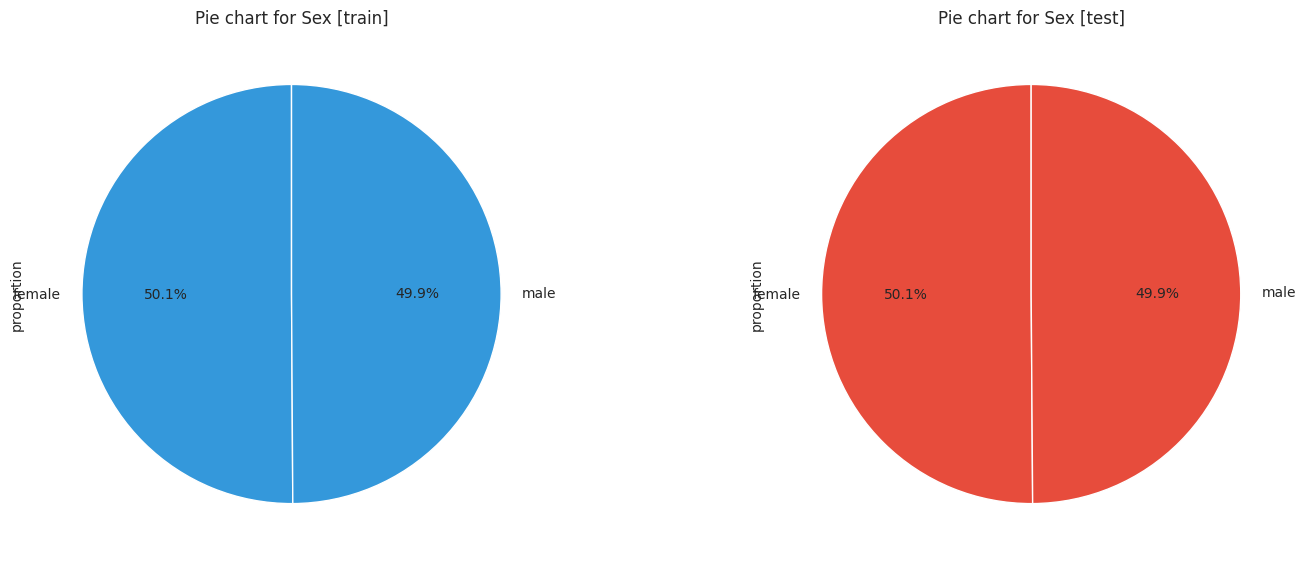

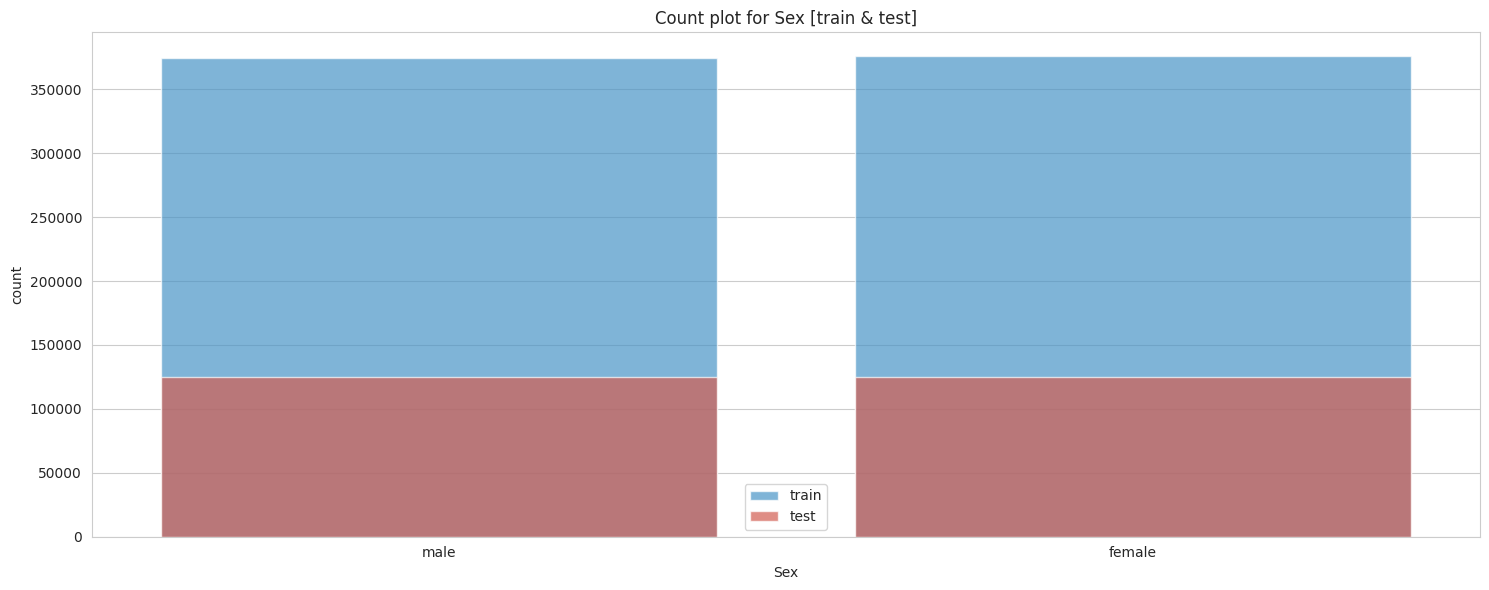

<Figure size 640x480 with 0 Axes>

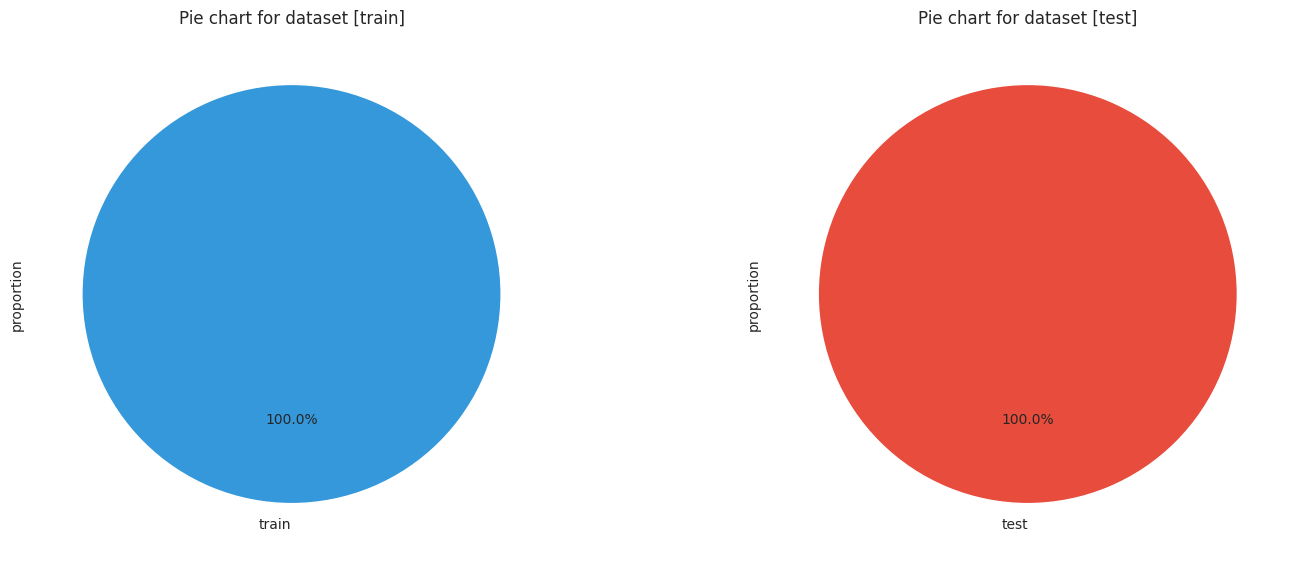

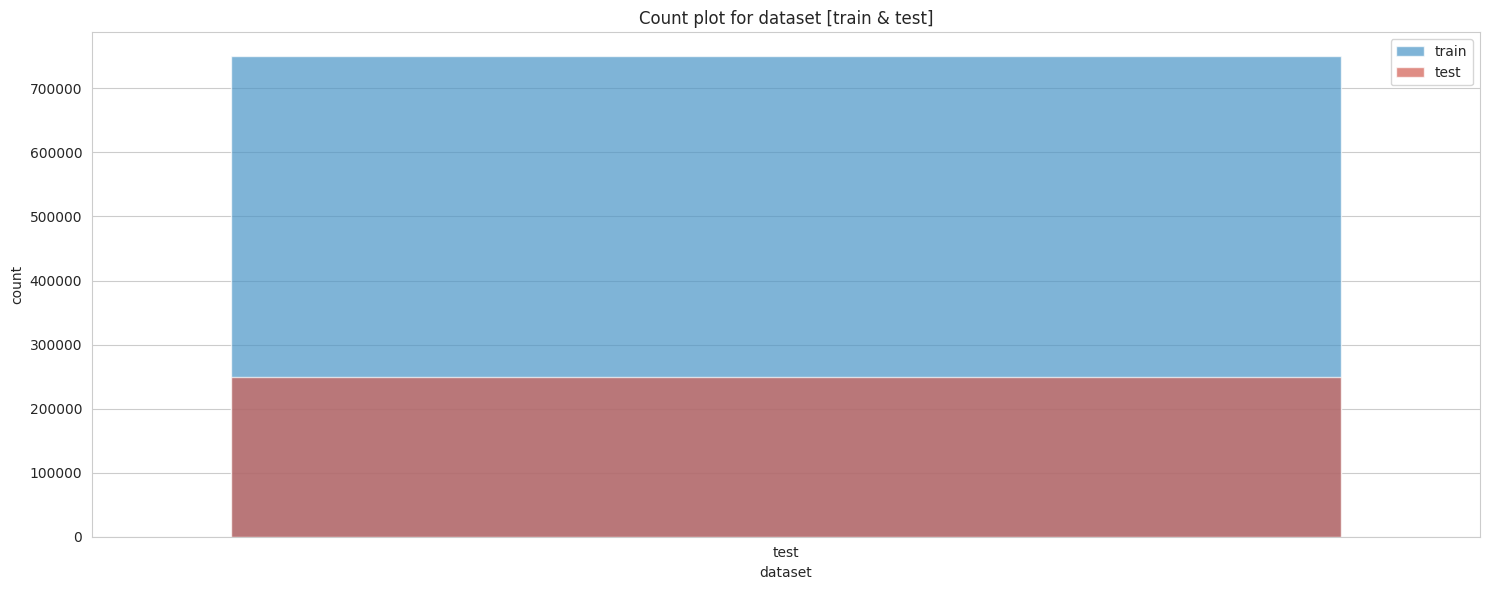

<Figure size 640x480 with 0 Axes>

In [14]:
# custom palette of colors
custom_palette = ['#3498db', '#e74c3c','#2ecc71']

# Add 'Dataset' column to distinguish between train and test data
df_train['dataset'] = 'train'
df_test['dataset'] = 'test'

# Create a list of variables (both numerical and categorical data)
numerical_variables = df_train.select_dtypes(include=['number']).columns
categorical_variables = df_train.select_dtypes(include=['object']).columns

# Create plots for numerical data
for variable in numerical_variables:
    create_variable_plots(variable, data_type='numerical')

# Create plots for categorical data
for variable in categorical_variables:
    create_variable_plots(variable, data_type='categorical')

# remove unnecessary columns
del df_train['dataset']
del df_test['dataset']

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>06 :⚖️📊 Train-test Comparability</div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ 1 : The ratios of categories in both "df_train" and "df_test" are roughly equal.<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : We don't need to perform preprocessing for 'df_train' and 'df_test', such as standardizing each dataframe.
  </div>

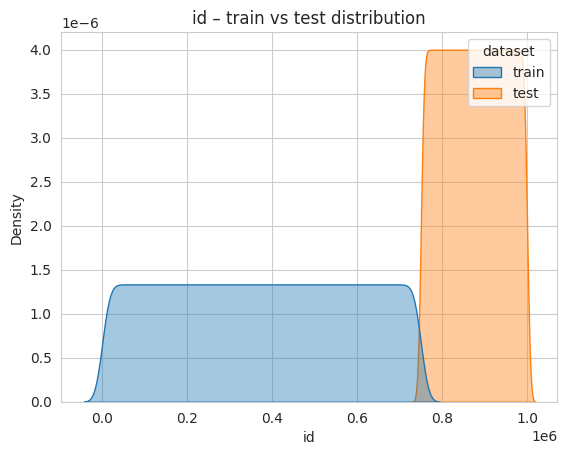

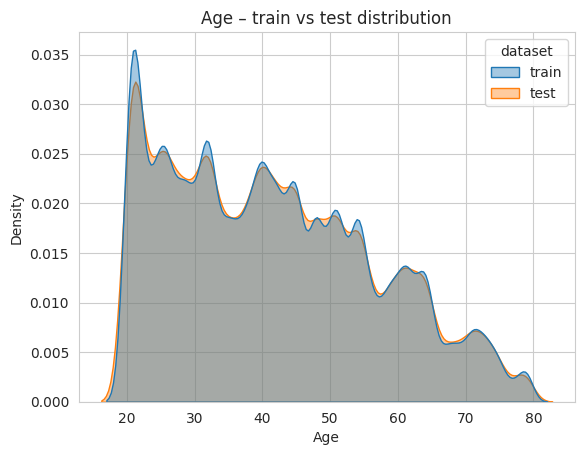

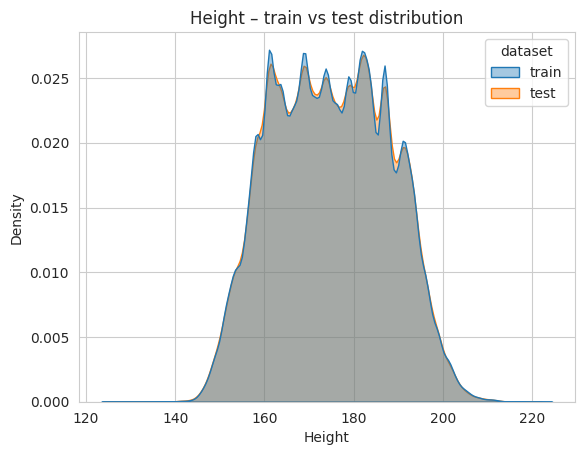

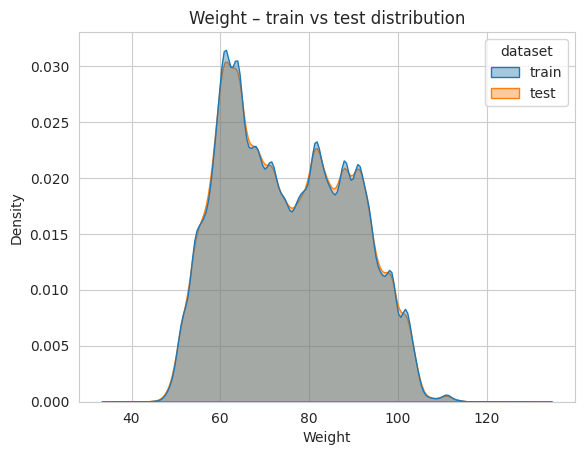

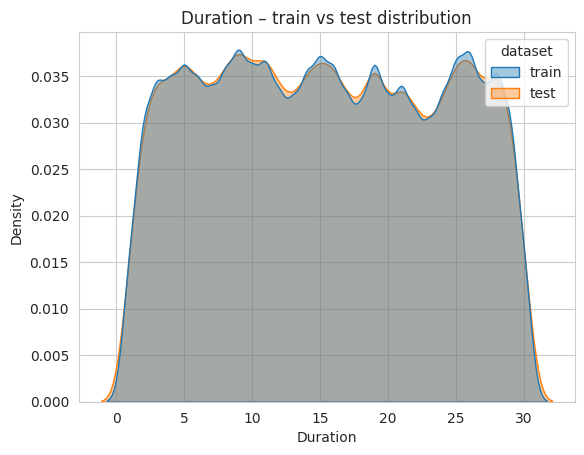

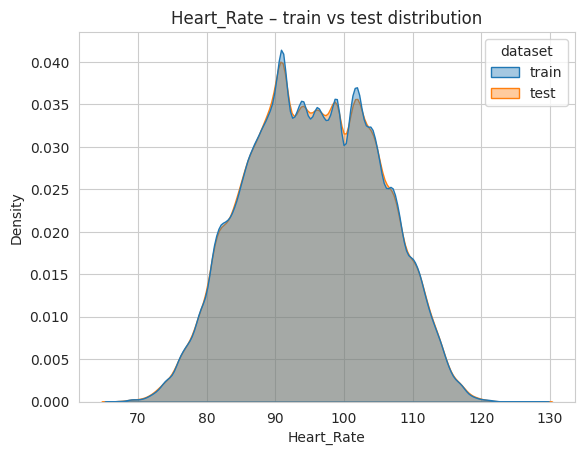

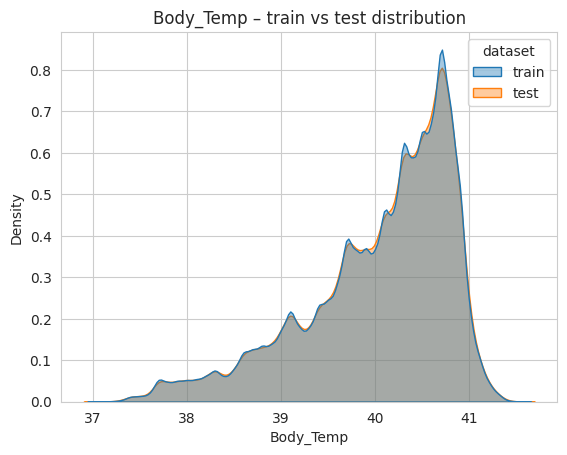

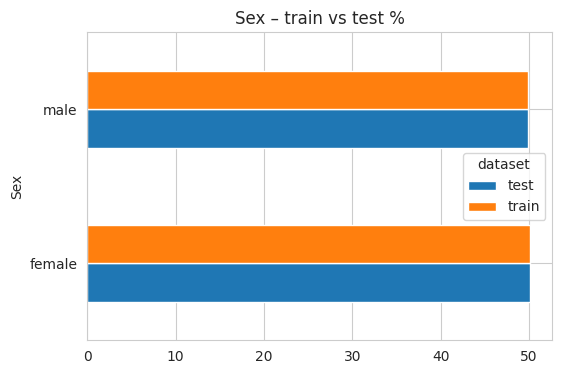

In [15]:
numerical_variables_tmp = pd.Index(numerical_variables[:-1], dtype='object').tolist()
categorical_variables_tmp = pd.Index(categorical_variables.drop('dataset'), dtype='object').tolist()

compare_cols = numerical_variables_tmp + categorical_variables_tmp
train_tag = df_train.assign(dataset = "train")[compare_cols + ["dataset"]]
test_tag  = df_test.assign(dataset = "test")[compare_cols + ["dataset"]]
combo = pd.concat([train_tag, test_tag], axis = 0)

for col in compare_cols:
    if col in categorical_variables_tmp:
        ct = pd.crosstab(combo[col], combo["dataset"], normalize = "columns") * 100
        ct.plot.barh(figsize = (6, 4), stacked=False, title = f"{col} – train vs test %")
        plt.show()
    else:
        sns.kdeplot(data = combo, x = col, hue = "dataset", fill = True, common_norm = False, alpha = 0.4)
        plt.title(f"{col} – train vs test distribution"); plt.show()

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>07 :↔️🔗 Vivariate</b></div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ 1 : The target variable (Calories) shows high correlation with the following variables:<br>
    &emsp;└ Duration<br>
    &emsp;└ Heart_Rate<br>
    &emsp;└ Body_Temp<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : We'll generate scatter plots of the target variable against other variables and examine them for categorical interactions.<br>
    See below for details.  </div>


### <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>🔥📊 Heat map</b></div>

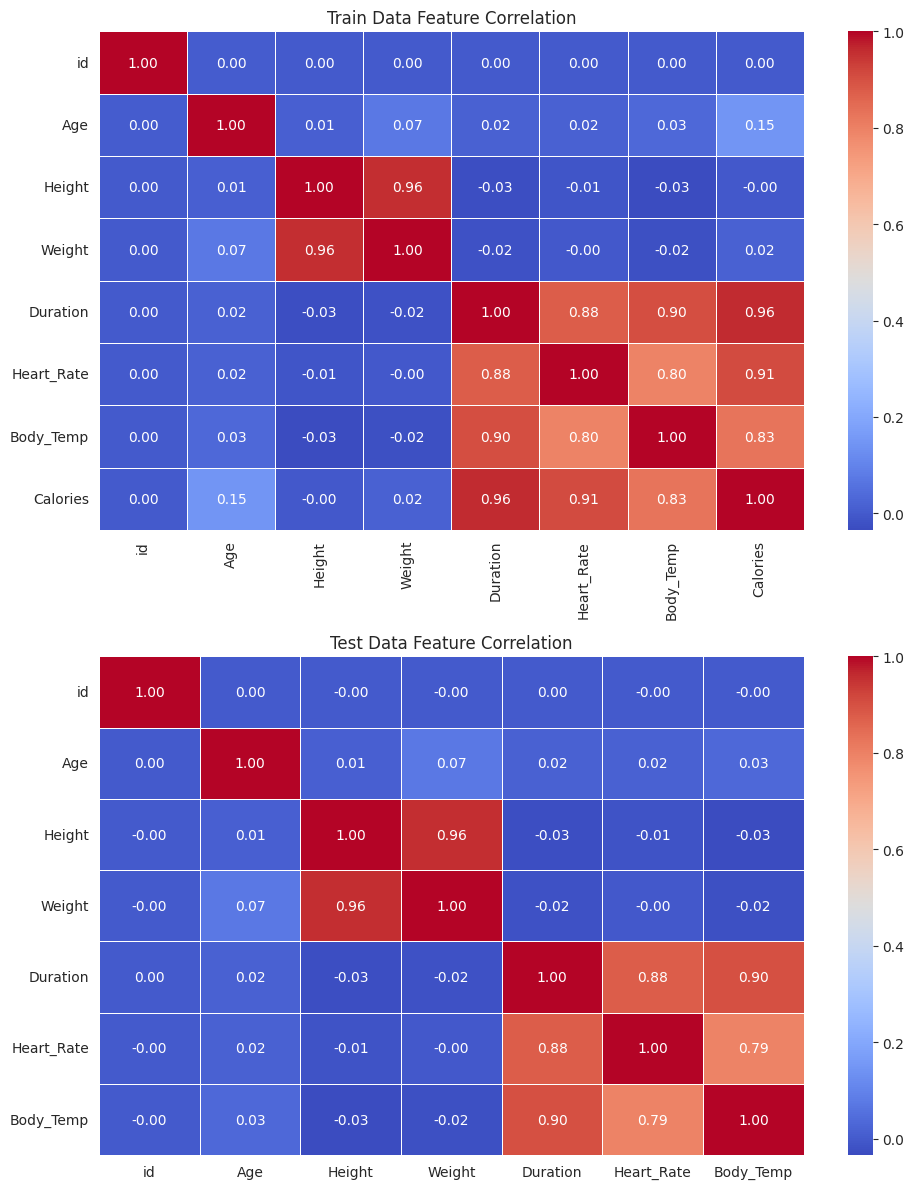

In [16]:
# Create a subplot (1 column, 2 rows)
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Correlation matrix of df_train
# (if necessary, extract only highly correlated variables.ex：mask=(corr < 0.8)))
sns.heatmap(df_train[numerical_variables].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[0])
axes[0].set_title('Train Data Feature Correlation')

# # Correlation matrix of df_test
# (if necessary, extract only highly correlated variables.ex：mask=(corr < 0.8)))
sns.heatmap(df_test[numerical_variables_tmp].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title('Test Data Feature Correlation')

# Layout adjustment
plt.tight_layout()
plt.show()

### <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>📊↔️ Pair plot</b></div>

Pairplot of Train Data


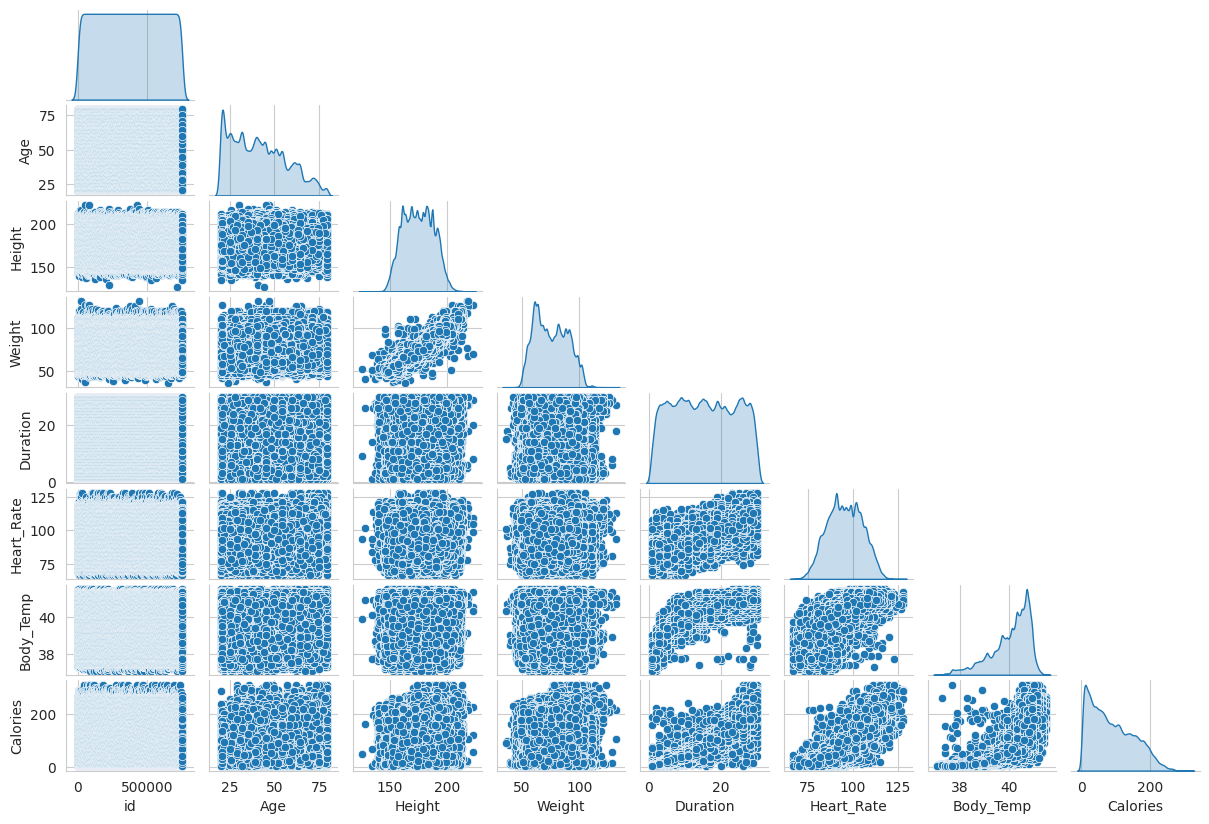

------------------------------------------------------------------------------------------------------
Pairplot of Test Data


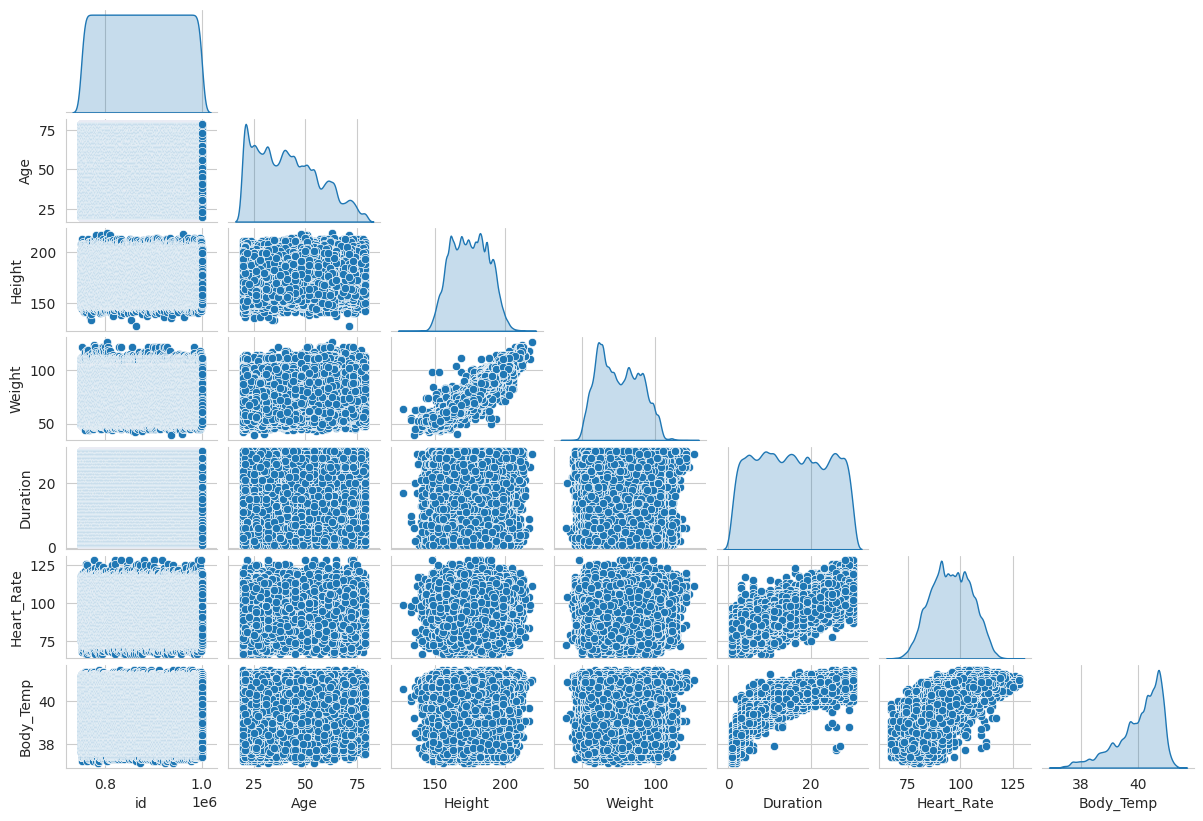

In [17]:
# Making Pairplot
print('Pairplot of Train Data')
grid_train = sns.pairplot(df_train[numerical_variables], corner = True, diag_kind = "kde")
grid_train.fig.set_size_inches(12, 8)
plt.show()

print('------------------------------------------------------------------------------------------------------')

print('Pairplot of Test Data')
grid_test = sns.pairplot(df_test[numerical_variables_tmp], corner = True, diag_kind = "kde")
grid_test.fig.set_size_inches(12, 8)
plt.show()

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>08 :🎯🔗 Relationship Between target variable and other variables</b></div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ 1 : When looking at average Calories by Age, Height, and Weight, we see instances of unusually low or high calorie values.<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : This variation likely stems from either limited sample sizes within those specific sub-groups or the existence of anomalous data points (outliers). <br>
&emsp;&emsp;Implementing methods like clipping could potentially enhance predictive accuracy.</div>

In [18]:
target_col = df_train.columns[-1]  #  object variable

# Get numeric and categorical columns
numeric_cols = df_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude the response variable from the numeric column
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Visualization settings
num_numeric = len(numeric_cols)
num_categorical = len(categorical_cols)

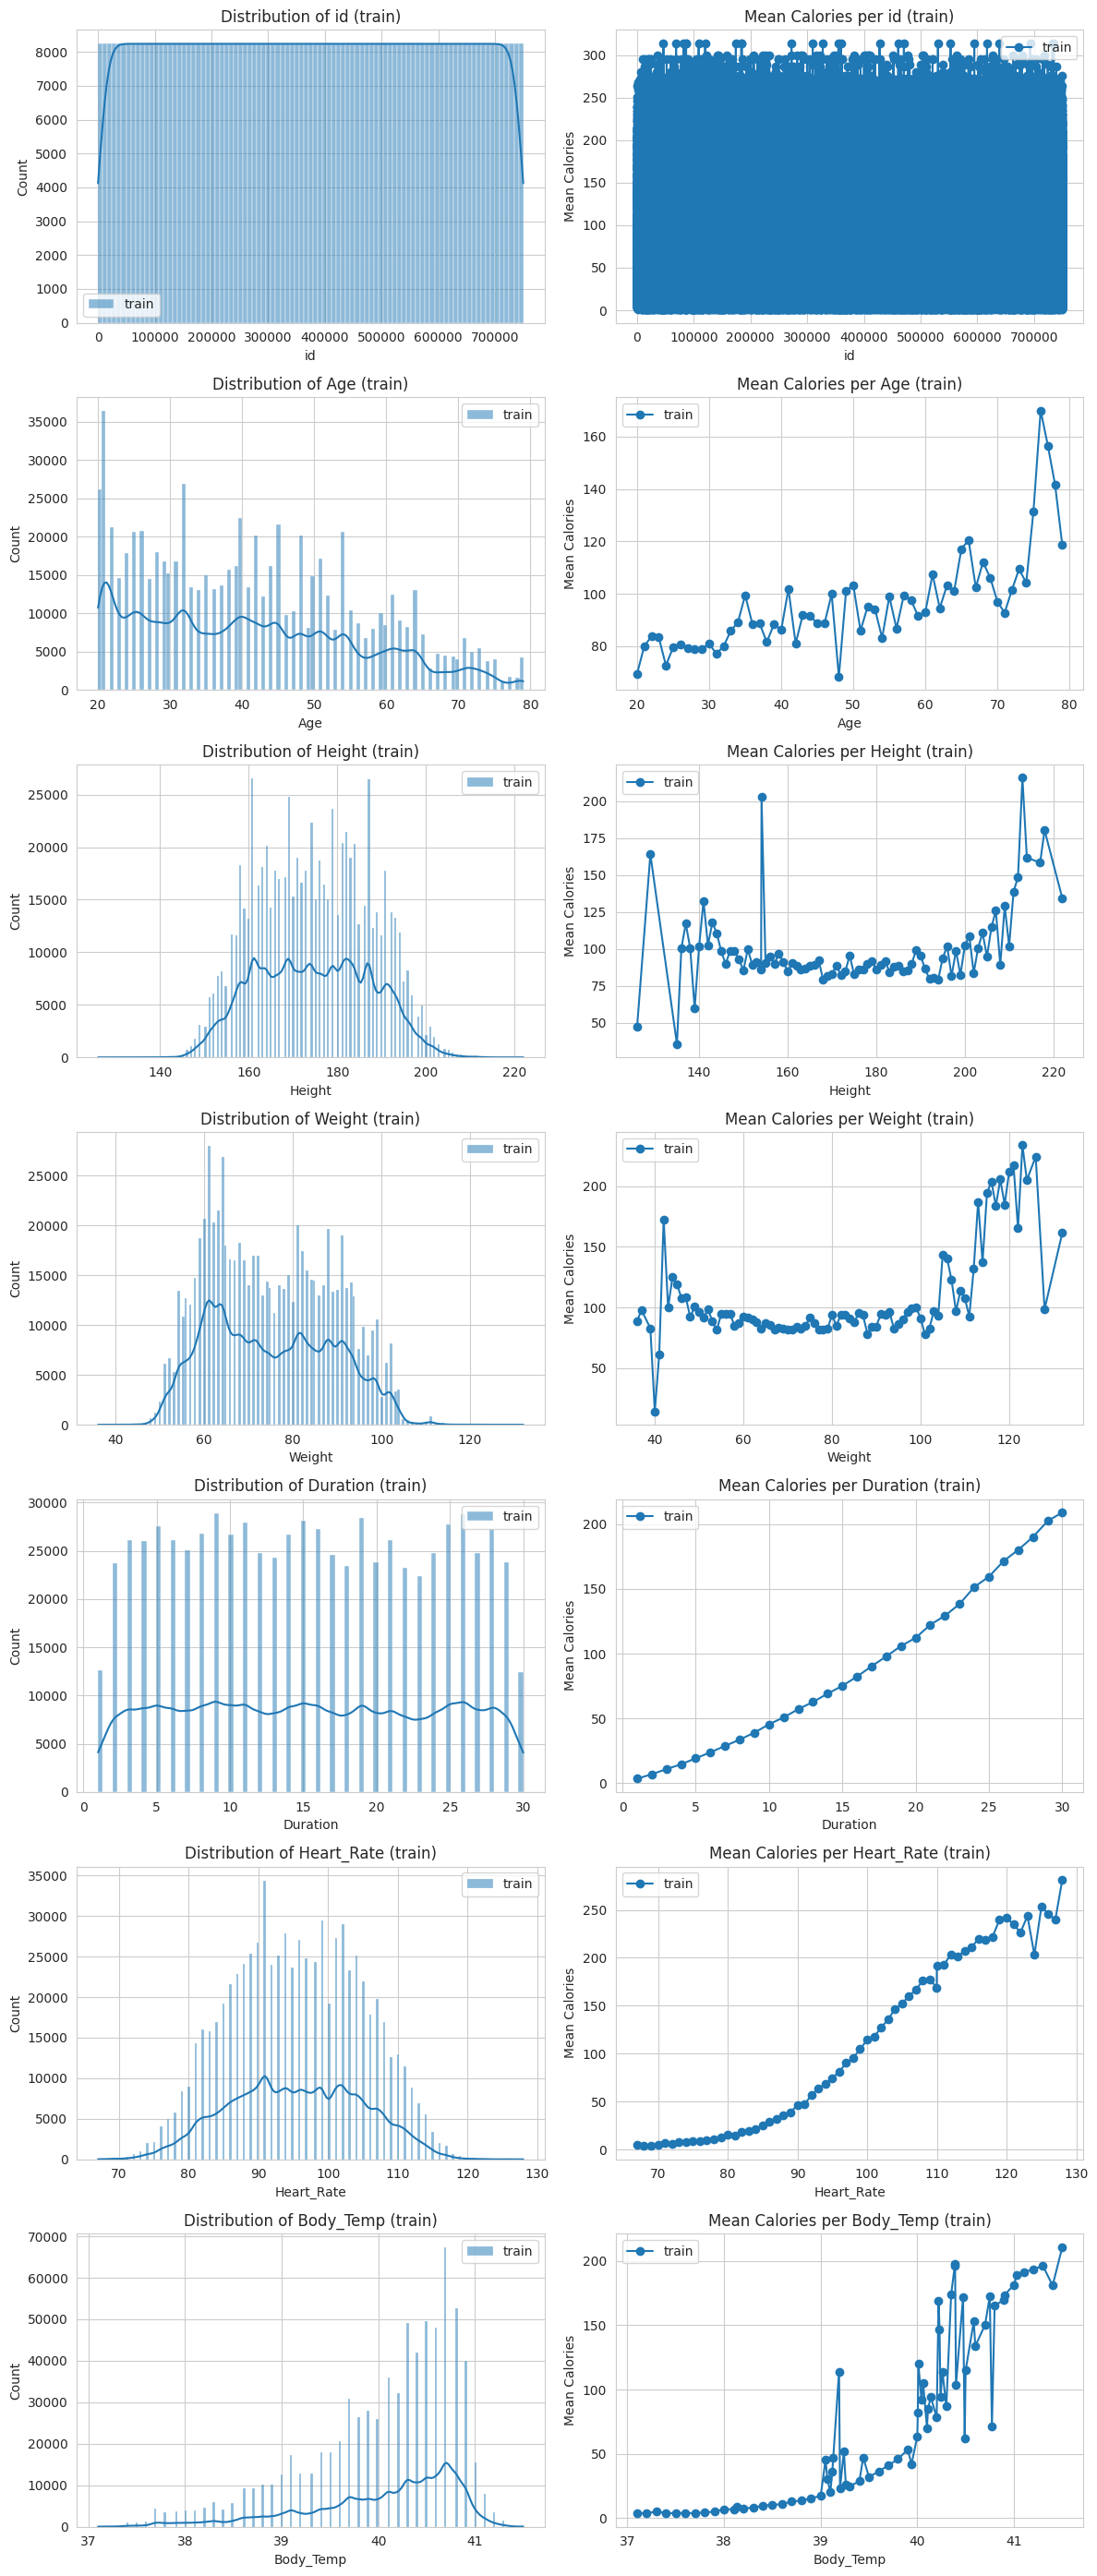

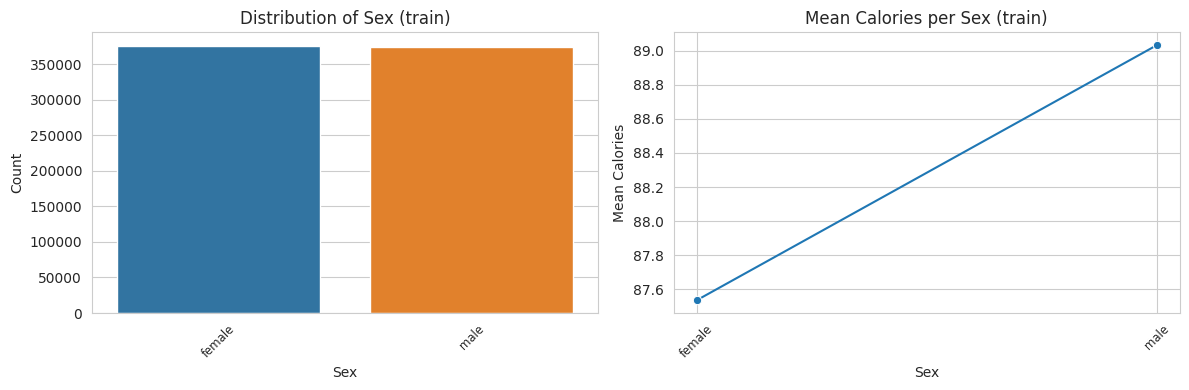

In [19]:
# Visualization of Numeric Variables 
if num_numeric > 0:
    fig_numeric, axes_numeric = plt.subplots(num_numeric, 2, figsize=(12, 4 * num_numeric))
    if num_numeric == 1:
        axes_numeric = axes_numeric.reshape(1, -1) # Treat even a single array as a 2D array
    for i, col in enumerate(numeric_cols):
        
        # Histograms and kernel density estimation
        sns.histplot(df_train[col], stat='count', kde=True, ax=axes_numeric[i, 0], label='train')
        # sns.histplot(df_train[col], stat='density', kde=True, ax=axes_numeric[i, 0], label='train')
        axes_numeric[i, 0].set_title(f'Distribution of {col} (train)')
        axes_numeric[i, 0].set_xlabel(col)
        axes_numeric[i, 0].set_ylabel('Count')
        # axes_numeric[i, 0].set_ylabel('Density')
        axes_numeric[i, 0].legend()

        # Line graph of univariate and dependent variable
        df_grouped_numeric = df_train.groupby(col)[target_col].mean().sort_index()
        axes_numeric[i, 1].plot(df_grouped_numeric.index, df_grouped_numeric.values, marker='o', linestyle='-', label='train')
        axes_numeric[i, 1].set_title(f'Mean {target_col} per {col} (train)')
        axes_numeric[i, 1].set_xlabel(col)
        axes_numeric[i, 1].set_ylabel(f'Mean {target_col}')
        axes_numeric[i, 1].grid(True)
        axes_numeric[i, 1].legend()
    plt.tight_layout()
    plt.show()

# Visualization of categorical variables
if num_categorical > 0:
    fig_categorical, axes_categorical = plt.subplots(num_categorical, 2, figsize=(12, 4 * num_categorical))
    if num_categorical == 1:
        axes_categorical = axes_categorical.reshape(1, -1) # Treat even a single array as a 2D array
    for i, col in enumerate(categorical_cols):
        
        # Frequency of categories
        sns.countplot(data=df_train, x=col, ax=axes_categorical[i, 0], order=df_train[col].value_counts().index)
        axes_categorical[i, 0].set_title(f'Distribution of {col} (train)')
        axes_categorical[i, 0].set_xlabel(col)
        axes_categorical[i, 0].set_ylabel('Count')
        axes_categorical[i, 0].tick_params(axis='x', rotation=45)
        axes_categorical[i, 0].tick_params(axis='x', labelsize='small')

        # Relationship between categories and objective variables (Line Plot)
        df_grouped_categorical = df_train.groupby(col)[target_col].mean().sort_index() # sort_index() を追加
        sns.lineplot(x=df_grouped_categorical.index, y=df_grouped_categorical.values, marker='o', linestyle='-', ax=axes_categorical[i, 1])
        axes_categorical[i, 1].set_title(f'Mean {target_col} per {col} (train)')
        axes_categorical[i, 1].set_xlabel(col)
        axes_categorical[i, 1].set_ylabel(f'Mean {target_col}')
        axes_categorical[i, 1].grid(True)
        axes_categorical[i, 1].tick_params(axis='x', rotation=45)
        axes_categorical[i, 1].tick_params(axis='x', labelsize='small')

    plt.tight_layout()
    plt.show()

In [20]:
# for col in numerical_variables_tmp:
#     plt.figure(figsize = (15,6))
#     sns.scatterplot(x = df_train[col], y = df_train[df_train.columns[-1]], alpha = 0.2)
#     sns.regplot(x = df_train[col], y = df_train["Calories"], scatter = False, color = "red")
#     plt.title(f"{col} vs Calories")
#     plt.show()

In [21]:
# # 'Sex'をカテゴリ変数として相互作用を確認する例
# numerical_variables_tmp = ['Duration', 'Heart_Rate', 'Body_Temp'] # 例として

# for col in numerical_variables_tmp:
#     plt.figure(figsize = (10, 6))
#     # カテゴリ変数（例: 'Sex'）で色分けして散布図をプロット
#     sns.scatterplot(x = df_train[col], y = df_train["Calories"], hue = df_train["Sex"], alpha = 0.6)
#     # 各カテゴリごとに回帰直線を描画
#     sns.regplot(x = df_train[col], y = df_train["Calories"], data=df_train[df_train['Sex'] == 'Male'], scatter = False, color = "blue", label = "Male Trend")
#     sns.regplot(x = df_train[col], y = df_train["Calories"], data=df_train[df_train['Sex'] == 'Female'], scatter = False, color = "orange", label = "Female Trend")
    
#     plt.title(f"{col} vs Calories by Sex")
#     plt.legend()
#     plt.grid(True, linestyle='--', alpha=0.7)
#     plt.show()

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>09 :⚠️🔗 VIF (Multicolinearity Check)</div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ 1 : Both Weight and Height show very high VIFs, in the range of 12.7, in both df_train and df_test.<br>
    └ 2 : Duration is also concerning at 8.5, and Body_Temp is at 5.4, both exceeding the VIF threshold of 5.<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : Variables with a high VIF can be addressed by selecting or reducing variables, creating new variables through feature engineering or dimensionality reduction techniques like Principal Component Analysis (PCA), or by using regularization methods. <br>

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Tips : What is VIF?</strong>
  </h5>
    └ VIF stands for Variance Inflation Factor. In regression analysis, it's a metric that indicates how much a given explanatory (or predictor) variable is correlated with other explanatory variables in the model, and how much that correlation inflates the variance of its regression coefficient.<br>
&emsp;Put simply, a higher VIF means that the explanatory variable is strongly correlated with other explanatory variables.<br>
&emsp;As a result, the estimation of that variable's regression coefficient becomes unstable, which leads to a larger standard error.<br>
&emsp;（VIF is extremely useful for assessing the health of a regression model and for obtaining reliable results.）<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Interpreting VIF Values:</strong>
      </h5>
    &emsp;  └ VIF = 1:<br>
    &emsp;&emsp;  └ This indicates no correlation with other explanatory variables at all. There's no multicollinearity present.<br>
    &emsp;  └ VIF < 5:<br>
    &emsp;&emsp;  └ Multicollinearity is often considered to be a minor issue in this range. It's generally acceptable in most cases.<br>
    &emsp;  └ VIF ≥ 5 (or VIF ≥ 10):<br>
    &emsp;&emsp;  └ This suggests that multicollinearity is likely present.<br>
    &emsp;&emsp;&emsp;  In such cases, it's considered problematic, and you should consider addressing it.<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Strategies for Addressing High VIF:</strong>
      </h5>
    &emsp;└ If you've identified explanatory variables with high VIF values, consider the following approaches to mitigate multicollinearity:<br>
    &emsp;&emsp;  └ Remove Less Relevant Variables:<br>
    &emsp;&emsp;&emsp; └ From the group of variables with high VIF,<br>
    &emsp;&emsp;&emsp; consider removing those that have a low correlation with your dependent variable or are deemed less important based on domain knowledge.<br>
    <br>
    &emsp;&emsp;  └ Remove One of Highly Correlated Variables:<br>
    &emsp;&emsp;&emsp;  └ When dealing with a group of strongly correlated variables, remove either the one with the highest VIF or the one considered less critical.<br>
    <br>
    &emsp;&emsp;  └ Combine Variables:<br>
    &emsp;&emsp;&emsp;  └ Transform several highly correlated variables into a single, new composite variable (e.g., their average or sum).<br>
    <br>
    &emsp;&emsp;  └ Dimension Reduction Techniques like Principal Component Analysis (PCA):<br>
    &emsp;&emsp;&emsp;  └ Convert multiple correlated variables into new, orthogonal (uncorrelated) variables, known as principal components, thereby reducing the dimensionality.<br>
    <br>
    &emsp;&emsp;  └ Utilize Regularization Methods such as Ridge or Lasso Regression:<br>
    &emsp;&emsp;&emsp;  └ These techniques can help reduce the impact of multicollinearity and lead to more stable regression coefficients.<br>

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Tips : What is Multicollinearity?</strong>
  </h5>
    └ Multicollinearity refers to a state in a linear regression model where a strong correlation exists between two or more explanatory (or independent) variables.<br>
    The presence of multicollinearity can lead to the following issues:<br>
    <br>
    &emsp;└ Instability of Regression Coefficients:<br>
    &emsp;&emsp;  └ The estimated regression coefficients become unstable and can fluctuate significantly with minor changes in the data. <br>
    &emsp;&emsp;This makes it difficult to accurately assess the impact of individual variables.<br>
    <br>
    &emsp;└ Increased Standard Errors:<br>
    &emsp;&emsp;  └ The standard errors of the regression coefficients become larger, which can, in turn, make their statistical significance (p-values) unreliable.
<br>
    <br>
    &emsp;└ Difficulty in Interpretation:<br>
    &emsp;&emsp;  └ It becomes harder to distinguish which variables are truly influencing the dependent variable and what the specific contribution of each variable is.<br>
    <br>
    &emsp;└ Impact on Prediction Accuracy:<br>
    &emsp;&emsp;  └ While strict multicollinearity might not always directly affect predictive accuracy, it can increase the risk of overfitting and reduce the model's generalization performance.<br>
</div>

</div>

In [22]:
def calculate_vif(df: pd.DataFrame, numerical_cols: list):
    """
    Calculates and displays the VIF (Variance Inflation Factor) for a specified numeric column in a data frame.

    Args:
        df (pd.DataFrame): The dataframe over which to compute the VIF.
        numerical_cols (list): A list of the names of the numeric columns you want to calculate the VIF for.
                               Do not include the target variable in this list.
    Returns:
        pd.DataFrame: A data frame containing each feature and its VIF value.
    """
    # Create a data frame with only selected numeric columns
    X = df[numerical_cols]
    X_vif = add_constant(X)

    # Initialize a data frame to store the VIFs.
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

    # Display the VIF excluding the constant term (const)
    vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values("VIF", ascending=False)

    return vif_data

In [23]:
# df_train for VIF
df_train_vif = calculate_vif(df_train, numerical_variables_tmp)
df_train_vif = df_train_vif.rename(columns={'VIF': 'VIF_train'})

# df_test for VIF
df_test_vif = calculate_vif(df_test, numerical_variables_tmp)
df_test_vif = df_test_vif.rename(columns={'VIF': 'VIF_test'})

# Merge df_train_vif and df_test_vif
df_vif = pd.merge(df_train_vif, df_test_vif, how = 'inner', on = 'Feature').style.background_gradient(cmap="viridis")
df_vif

,Feature,VIF_train,VIF_test
0,Weight,12.766915,12.723028
1,Height,12.702173,12.657364
2,Duration,8.510598,8.502424
3,Body_Temp,5.434871,5.409066
4,Heart_Rate,4.285832,4.282299
5,Age,1.050877,1.050589
6,id,1.000010,1.000014


## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>10 :⚙️🔄 Principal Component Analysis</div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ 1 : Scree Plot:<br>
    &emsp;└ The cumulative explained variance accounts for approximately 77% up to the second principal component and about 91% up to the third principal component.<br>
    <br>
    └ 2 : Principal Component Loadings:<br>
    &emsp;└ The principal components yielded the following results:<br>
    &emsp;&emsp;└ PC1:<br>
    &emsp;&emsp;&emsp;└ High positive loadings: Height (0.37), Weight (0.37)<br>
    &emsp;&emsp;&emsp;└ High negative loadings: Duration (-0.46), Heart_Rate (-0.44), Body_Temp (-0.45)<br>
    &emsp;&emsp;└ PC2:<br>
    &emsp;&emsp;&emsp;└ High positive loadings: Sex (0.43), Height (0.45), Weight (0.47), Duration (0.36), Heart_Rate (0.36), Body_Temp (0.35)<br>
    &emsp;&emsp;└ PC3:<br>
    &emsp;&emsp;&emsp;└ Very high positive loading: Age (0.99)<br>
    &emsp;&emsp;└ PC4:<br>
    &emsp;&emsp;&emsp;└ High negative loading: Sex (-0.82)<br>
    &emsp;&emsp;└ PC5:<br>
    &emsp;&emsp;&emsp;└ High positive loading: Heart_Rate (0.75)<br>
    &emsp;&emsp;&emsp;└ High negative loading: Body_Temp (-0.65)<br>
    <br>
    └ 3 : Scatter Plot:<br>
    &emsp;└ Scatter Plot yielded the following results:<br>
    &emsp;&emsp;└ Quintile 0 (Purple):<br>
    &emsp;&emsp;&emsp;└ This group, representing the lowest calorie consumption, is largely distributed towards the positive direction (right side) of PC1.<br>
    &emsp;&emsp;└ Quintile 1 (Dark Blue):<br>
    &emsp;&emsp;&emsp;└ Distributed slightly towards the positive direction of PC1.<br>
    &emsp;&emsp;└ Quintile 2 (Light Blue):<br>
    &emsp;&emsp;&emsp;└ Distributed around the center of PC1.<br>
    &emsp;&emsp;└ Quintile 3 (Green-Yellow):<br>
    &emsp;&emsp;&emsp;└ Distributed slightly towards the negative direction of PC1.<br>
    &emsp;&emsp;└ Quintile 4 (Yellow):<br>
    &emsp;&emsp;&emsp;└ This group, representing the highest calorie consumption, is largely distributed towards the negative direction (left side) of PC1.<br>
    
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : We will tentatively select up to the second or third principal component for further analysis if we do pca. <br>
    └ 2 : The principal components can be interpreted as follows: <br>
    &emsp;└ PC1: Represents the negative direction of "intensity of exercise activity / physical exertion."<br>
    &emsp;└ PC2: Represents "overall physical activity level and physique."<br>
    &emsp;└ PC3: Represents "age."<br>
    &emsp;└ PC4: Represents "sex."<br>
    &emsp;└ PC5: Represents the "relationship between heart rate and body temperature."<br>
    └ 3 : PCA has effectively extracted a primary pattern of variation (PC1) that is strongly correlated with the target variable.<br>
    &emsp;Specifically, we observed that PC1 alone can quite clearly distinguish between high and low calorie consumption.
  </h5>

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Tips : What is PCA(Principal Component Analysis)?</strong>
  </h5>
    └ It's a statistical technique used to reduce the dimensions of high-dimensional raw data while minimizing information loss.<br>
&emsp;Essentially, it's a method to summarize large datasets, transforming them into a simpler, smaller set of new information (principal components or columns), ensuring that the most crucial information (features) isn't lost.<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Reasons for Performing Principal Component Analysis (PCA):</strong>
      </h5>
    &emsp;  └ Understanding Overall Data Characteristics:<br>
    &emsp;  └ Dimensionality Reduction:<br>
    &emsp;  └ Resolving Multicollinearity:<br>
    &emsp;  └ Noise Reduction:<br>
    &emsp;  └ Feature Engineering:<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Basic Idea:</strong>
      </h5>
    &emsp;└ The goal is to find new axes (principal components) that maximize the preservation of "variance" within the information held by the original data.<br>
    &emsp;&emsp;  └ First Principal Component (PC1):<br>
    &emsp;&emsp;&emsp; └ Finds the axis that best explains the overall variance (spread of information) in the data.<br>
    &emsp;&emsp;  └ Second Principal Component (PC2):<br>
    &emsp;&emsp;&emsp; └ Finds an axis that is orthogonal (uncorrelated) to the first principal component and best explains the remaining variance.<br>
    &emsp;&emsp;  └ Subsequent Principal Components:<br>
    &emsp;&emsp;&emsp; └ Similarly, these are found by being orthogonal to the preceding principal components and maximizing the explanation of the remaining variance.<br>
    &emsp;└ The principal components found in this way are expressed as a linear combination (weighted sum) of the original variables.<br>
&emsp;&emsp;  Each principal component has an "explained variance ratio" indicating what proportion of the information (variance) contained in the original data it explains.<br>
    &emsp;└ In data, "variance" directly represents the amount of "variation" or "features" that the data possesses, as well as its "discriminatory power."<br>
&emsp;&emsp;  Therefore, the greater the variance, the more "information" the data can be considered to hold.<br>
&emsp;&emsp;  PCA seeks axes that maximize variance precisely to efficiently compress the "information".<br>
    &emsp;└ Since not all information from the original data is retained, interpretability may be reduced.<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Deciding Whether to Perform PCA Based on Data Characteristics:</strong>
      </h5>
    &emsp;└ Dimensionality:<br>
    &emsp;&emsp;  └ Low-dimensional data: If the number of original explanatory variables is small (e.g., a few to about a dozen), PCA may not be necessary.<br>
    &emsp;&emsp;  └ High-dimensional data: If the number of explanatory variables is very large (hundreds to thousands, or more), PCA is often beneficial.
<br>
    &emsp;└ Data with Multicollinearity:<br>
    &emsp;&emsp;  └ If there are strong correlations among explanatory variables, it may be beneficial to perform PCA. 

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Deciding Whether to Perform PCA Based on Data Characteristics:</strong>
      </h5>
    &emsp;└ Dimensionality:<br>
    &emsp;&emsp;  └ Low-dimensional data: If the number of original explanatory variables is small (e.g., a few to about a dozen), PCA may not be necessary.<br>
    &emsp;&emsp;  └ High-dimensional data: If the number of explanatory variables is very large (hundreds to thousands, or more), PCA is often beneficial.
<br>
    &emsp;└ Data with Multicollinearity:<br>
    &emsp;&emsp;  └ If there are strong correlations among explanatory variables, it may be beneficial to perform PCA. 

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Regarding Scree Plot and Principal Component Loadings</strong>
  </h5>
    └ Scree Plot:<br>
&emsp;&emsp; └ graphical representation of the results of Principal Component Analysis (PCA).<br>
&emsp;&emsp; It visually displays how much information (variance) each principal component explains, both individually and cumulatively.<br>
&emsp;&emsp; This plot is useful for determining the optimal number of principal components to retain.<br>
    └ Principal Component Loadings:<br>
    &emsp;└ numerical values that indicate which of the original variables (features) strongly constitute or influence each principal component.<br>
    &emsp;&emsp; They are crucial for interpreting which aspects of the original data each principal component captures.
</div>

</div>

In [24]:
# value for mapping 
mapping = {'male': 1, 'female': 0}

# df_train_tmp
df_train_tmp = df_train.drop(['id'], axis=1)
df_train_tmp['Sex'] = df_train_tmp['Sex'].replace(mapping)

# selecting numeric columns
numerical_variables_for_pca = df_train_tmp.select_dtypes(include=['number']).columns
numerical_variables_for_pca = pd.Index(numerical_variables_for_pca[:-1], dtype='object').tolist()

In [25]:
# Sampling
n_samples_total = df_train_tmp.shape[0] # Total number of data
sample_percentage = 0.05                # Setting the sampling rate
n_samples_for_analysis = int(n_samples_total * sample_percentage)

# Randomly select n_samples_for_analysis rows from df_train_tmp
df_train_tmp = df_train_tmp.sample(n=n_samples_for_analysis, random_state=42).copy()

print(f"Number of original data: {n_samples_total} records")
print(f"Number of data points after sampling: {df_train_tmp.shape[0]} records")

Number of original data: 750000 records
Number of data points after sampling: 37500 records


In [26]:
df_train_pca_target = df_train_tmp[numerical_variables_for_pca + [df_train_tmp.columns[-1]]].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_train_pca_target[numerical_variables_for_pca])

# Running PCA
pca = PCA(n_components=5, random_state=42)
pca_result = pca.fit_transform(scaled_data)

# Calculating quantiles of the response variable
target_quintiles = pd.qcut(df_train_pca_target[df_train.columns[-1]], 5, labels=False, duplicates='drop')

'The proportion of variance each principal component explains: [0.39540763 0.37766827 0.1429268  0.03900643 0.02925532]'

'Cumulative explained variance ratio: 0.98'

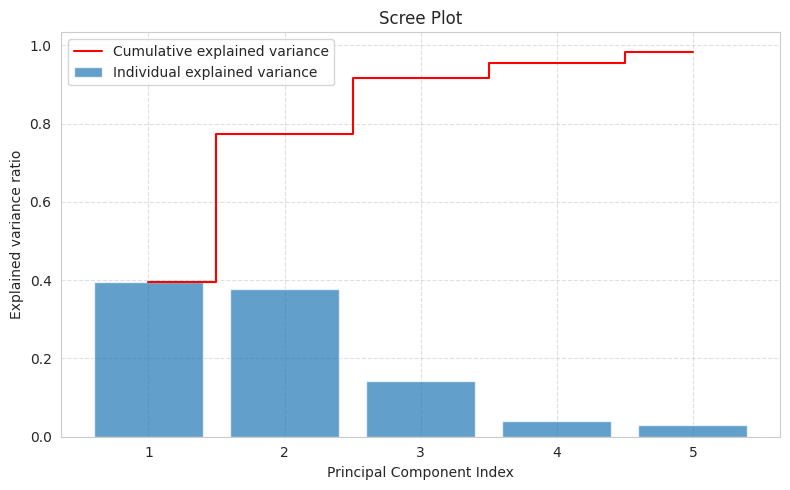

In [27]:
# Scree plot
# The proportion of variance each principal component explains
explained_variance_ratio = pca.explained_variance_ratio_
display(f"The proportion of variance each principal component explains: {explained_variance_ratio}")
display(f"Cumulative explained variance ratio: {explained_variance_ratio.sum():.2f}")

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, align='center', label='Individual explained variance')
plt.step(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), where='mid', label='Cumulative explained variance', color='red')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

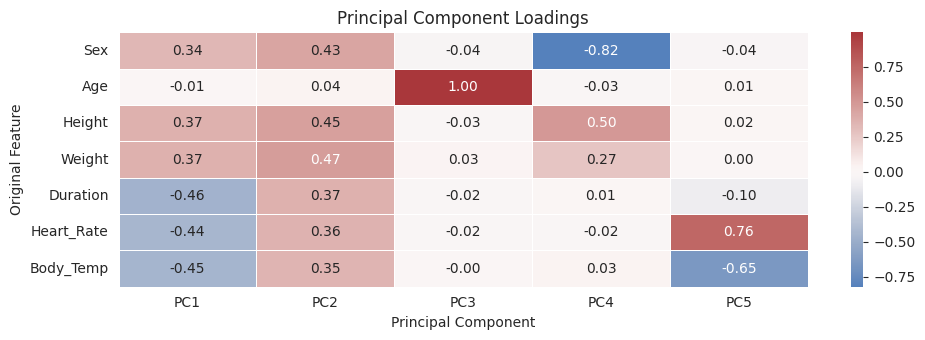

In [28]:
# Principal Component Loadings
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components)], index=numerical_variables_for_pca)

plt.figure(figsize=(10, len(numerical_variables_for_pca) * 0.5))
sns.heatmap(loadings, cmap='vlag', annot=True, fmt=".2f", linewidths=.5, center=0)
plt.title('Principal Component Loadings')
plt.xlabel('Principal Component')
plt.ylabel('Original Feature')
plt.tight_layout()
plt.show()

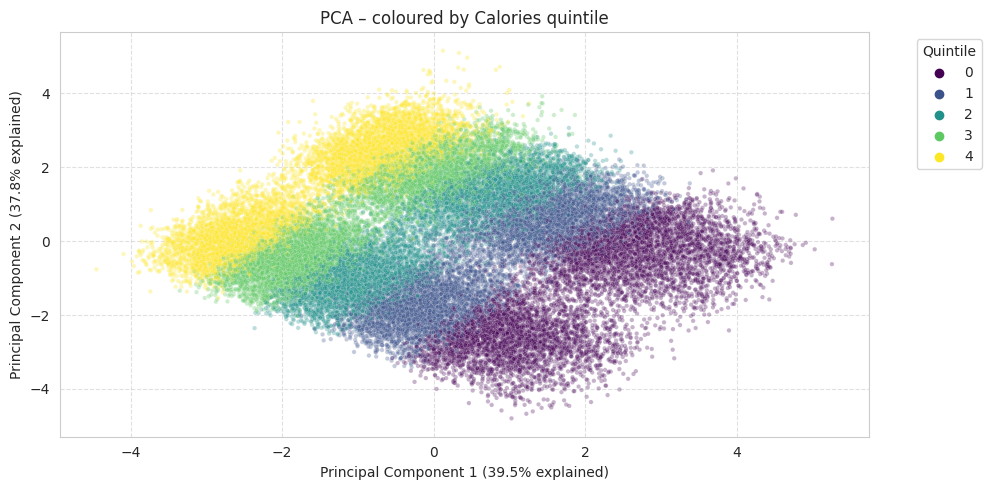

In [29]:
# Drawing a scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(x=pca_result[:, 0],
                y=pca_result[:, 1],
                hue=target_quintiles,
                palette="viridis",
                alpha=0.3,
                s=10)

# Add explanatory variance contributions to axis labels
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.1f}% explained)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.1f}% explained)')
plt.title(f"PCA – coloured by {df_train.columns[-1]} quintile")

# Adjust the legend position
plt.legend(title="Quintile", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>11 :📍🧩 Kmeans</div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
    └ 1 : Search for the optimal K<br>
    &emsp;└ Elbow Method:<br>
    &emsp;&emsp;└ The decrease in Inertia appears to become relatively gradual around K=3 or K=4.<br>
    &emsp;&emsp;&emsp;While there is a significant decrease from K=2 to K=3, and a moderate decrease from K=3 to K=4, the slope of the decrease gradually becomes smaller from K=4 onwards.<br>
    &emsp;└ Silhouette Score:<br>
    &emsp;&emsp;└ The silhouette score is highest at K=2 (approximately 0.32), and then gradually decreases as K increases.<br>
    &emsp;&emsp;&emsp;The score shows a slight dip at K=3, a small recovery at K=4, but a continuous decline from K=5 onwards.<br>
    &emsp;└ Silhouette diagram:<br>
    &emsp;&emsp;└ The average score for n_clusters = 2 is the highest.<br>
    └ 2 : K-Means<br>
    &emsp;└ The dividing line of the K-Means cluster (left) and the boundary of the gradient of the calorie consumption quantiles (right) almost coincide on the PC1 axis.<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
    └ 1 : K=2 is considered optimal by the Silhouette Score, while the Elbow Method suggests K=3 or K=4 as optimal K values. <br>
    &emsp;&emsp;Looking at the silhouette diagram for n_clusters = 2, the silhouettes of each cluster are relatively neatly aligned, so K=2 is likely to produce good clustering results. <br>
    └ 2 : K-Means clustering (K=2) successfully dichotomizes the data points based on PC1, the dominant axis of variation in the data. <br>

<div style="background-color: #A08D00; border-left: 8px solid #8B7700; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Tips : What is K-means Clustering?</strong>
  </h5>
    └ K-means clustering is one of the most popular and widely used unsupervised machine learning algorithms.<br>
    &emsp;Its primary goal is to group unlabeled data points into clusters based on their similarity.<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Basic Idea:</strong>
      </h5>
    &emsp;└ K-means is a centroid-based clustering algorithm.<br>
    &emsp;This means that each cluster is represented by its center, known as a centroid (or mean).<br>
    &emsp;The algorithm's objective is to minimize the sum of distances between each data point and the centroid of its assigned cluster..<br>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #8B7700; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Basic Steps:</strong>
      </h5>
    &emsp;└ 1 : Specify K:<br>
    &emsp;&emsp;  └ First, you need to predetermine how many clusters you want to divide the data into.<br>
    &emsp;&emsp;  This value, "K," is specified by the user. The "K" in "K-means" refers to this number of clusters.<br>
    <br>
    &emsp;└ 2 : Initialize Centroids:<br>
    &emsp;&emsp;  └ Randomly select K data points from your dataset and set them as the initial cluster centroids.<br>
    <br>
    &emsp;└ 3 : Assign Data Points:<br>
    &emsp;&emsp;  └ For each data point, find the closest centroid among the K centroids and assign that data point to the cluster associated with that closest centroid.<br>
    &emsp;&emsp;  Euclidean distance is commonly used for distance calculation.<br>
    <br>
    &emsp;└ 4 : Update Centroids:<br>
    &emsp;&emsp;  └ Calculate the average (mean) of all data points assigned to each cluster and set this as the new centroid for that cluster.<br>
    <br>
    &emsp;└ 5 : Check for Convergence and Repeat:<br>
    &emsp;&emsp;  └ Repeat steps 3 and 4 until the positions of the centroids no longer significantly change, or the cluster assignments of the data points no longer change.<br>
    &emsp;&emsp;  This state is considered when the algorithm has "converged."
</div>

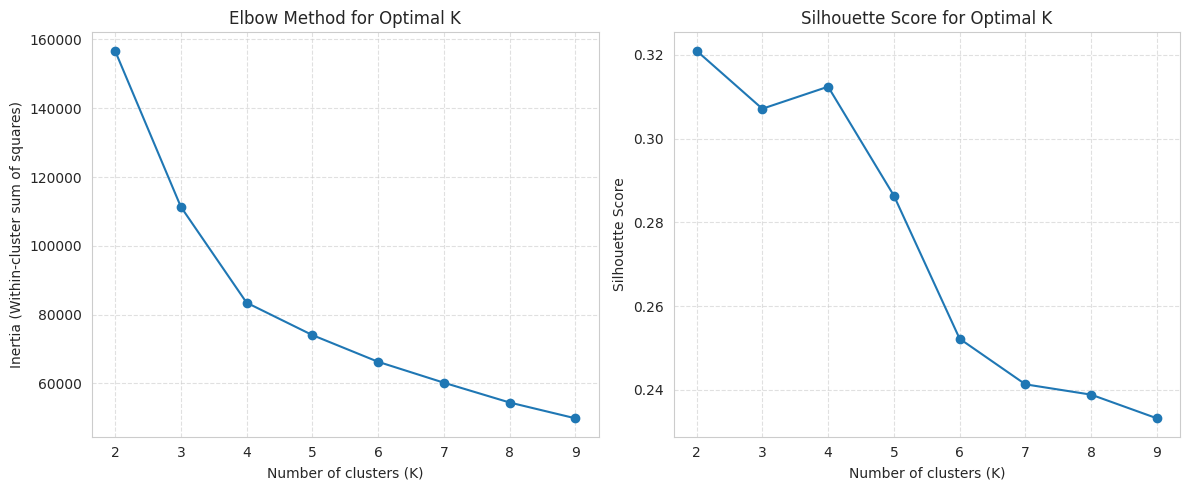


K-Means: Elbow Method (Inertia): [156737.1492190304, 111358.16797640498, 83448.69023205896, 74030.22722290456, 66256.7820182957, 60175.494196247724, 54413.48268010029, 49816.38506377819]
K-Means: silhouette score: [0.32098866990553154, 0.30712930741928113, 0.3123968922927534, 0.28638144165530066, 0.2521995467150488, 0.2413160211909545, 0.2388493813470682, 0.23319657110592487]


In [30]:
# Determining the optimal number of clusters K (elbow method and silhouette score)
# Specify the range of clusters to try
k_range = range(2, 6)
inertia = []           # SSB (Sum of Squared Distances to Centroids) for each K
silhouette_scores = [] # # Silhouette score for each K

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # kmeans.fit(pca_result)
    kmeans.fit(pca_result[:,0:3])
    inertia.append(kmeans.inertia_) # WCSS (Within-Cluster Sum of Squares)

    # Since silhouette scores cannot be calculated when K=1, they are calculated only when K > 1.
    if k > 1:
        silhouette_scores.append(silhouette_score(pca_result, kmeans.labels_))

# Drawing Elbow Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True, linestyle='--', alpha=0.6)

# Drawing silhouette score plots
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nK-Means: Elbow Method (Inertia):", inertia)
print("K-Means: silhouette score:", silhouette_scores)


For n_clusters = 2
The average silhouette_score is : 0.32098866990553154


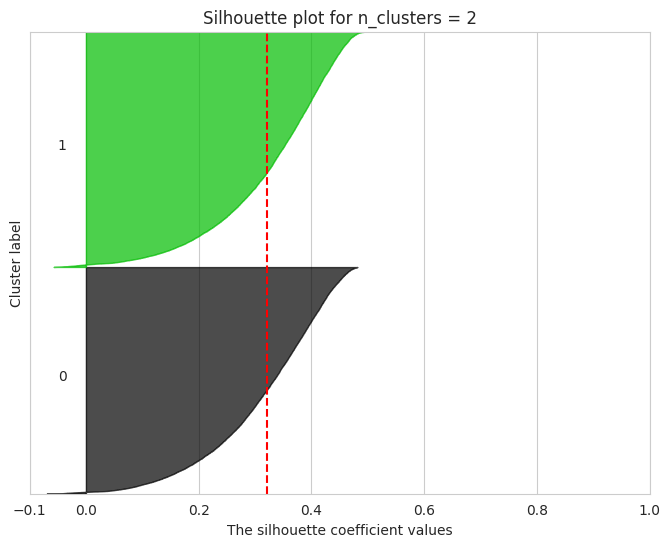


For n_clusters = 3
The average silhouette_score is : 0.30712930741928113


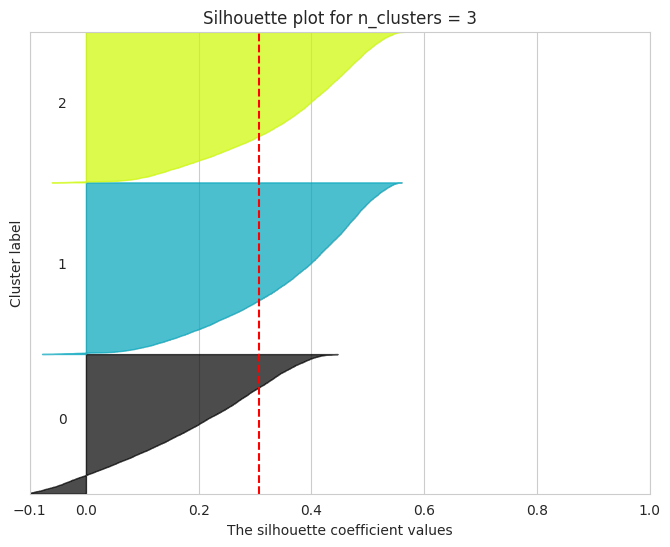


For n_clusters = 4
The average silhouette_score is : 0.3123968922927534


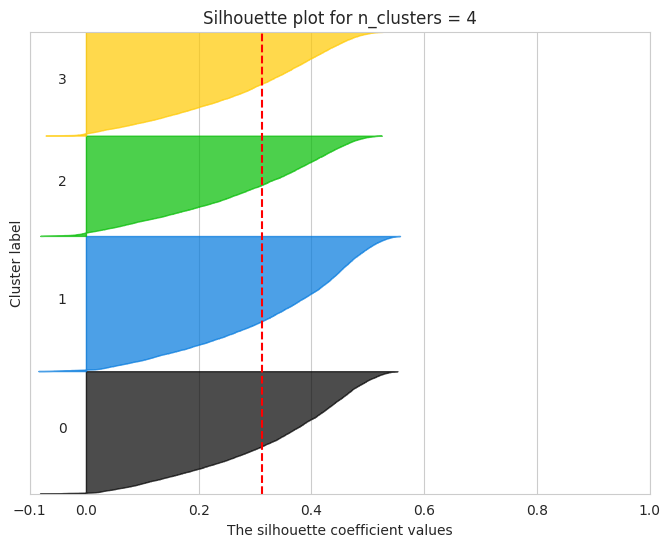


For n_clusters = 5
The average silhouette_score is : 0.28638144165530066


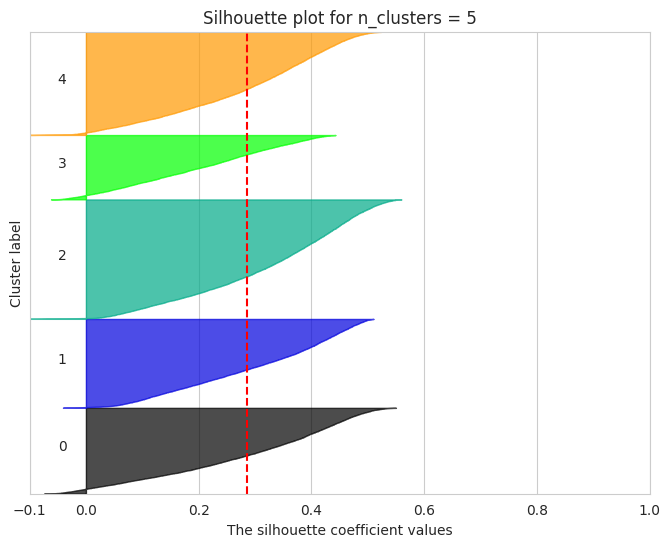


For n_clusters = 6
The average silhouette_score is : 0.2521995467150488


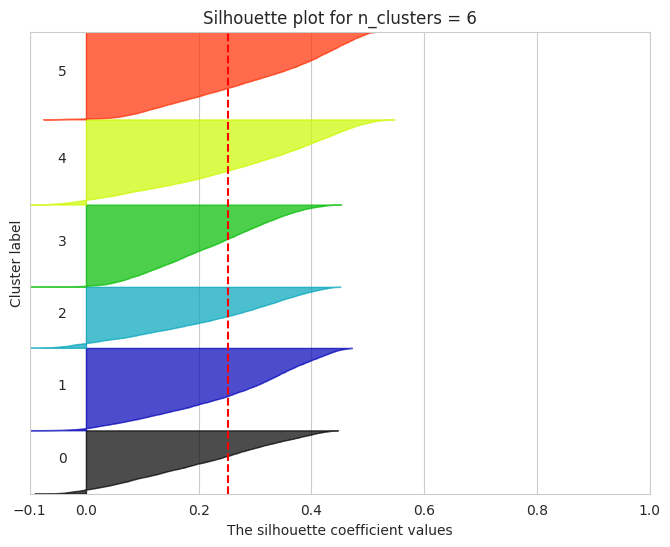


For n_clusters = 7
The average silhouette_score is : 0.2413160211909545


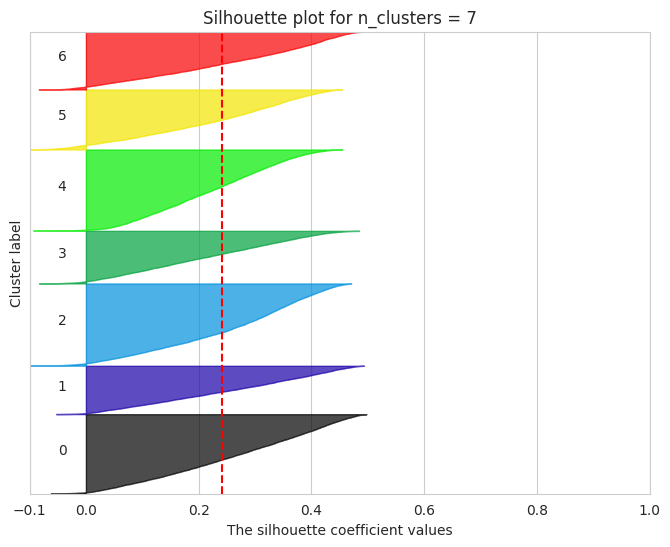


For n_clusters = 8
The average silhouette_score is : 0.2388493813470682


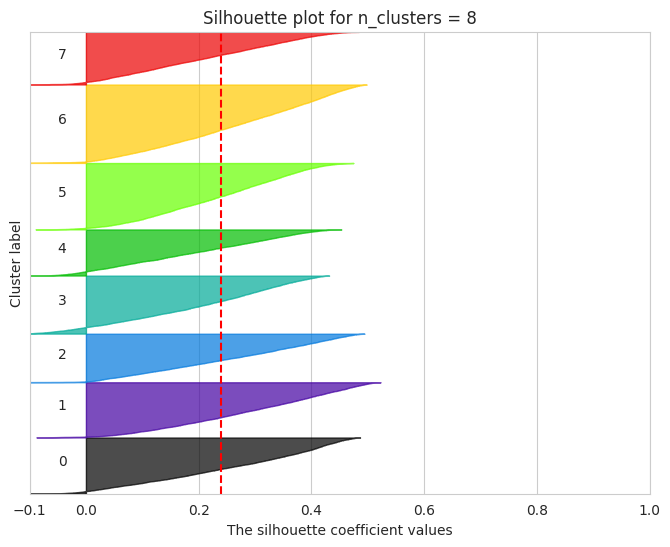


For n_clusters = 9
The average silhouette_score is : 0.23319657110592487


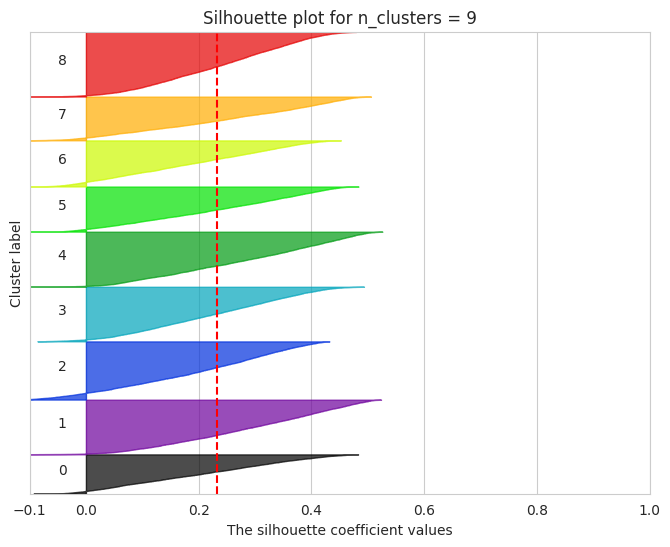


--- Summary of Silhouette Scores ---
n_clusters = 2: Silhouette Score = 0.3210
n_clusters = 3: Silhouette Score = 0.3071
n_clusters = 4: Silhouette Score = 0.3124
n_clusters = 5: Silhouette Score = 0.2864
n_clusters = 6: Silhouette Score = 0.2522
n_clusters = 7: Silhouette Score = 0.2413
n_clusters = 8: Silhouette Score = 0.2388
n_clusters = 9: Silhouette Score = 0.2332

Optimal K based on highest silhouette score: 2 (Score: 0.3210)


In [31]:
# Silhouette diagram
# Define the range of K you want to evaluate
# Since the silhouette score is not defined for one cluster, it is common to start with K at 2.
range_n_clusters = range(2, 6)

silhouette_scores = {} # A dictionary to store the silhouette scores for each K

for n_clusters in range_n_clusters:
    # Rerun K-Means with the optimal K (change n_clusters to the loop variable)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    # cluster_labels = kmeans.fit_predict(pca_result)
    cluster_labels = kmeans.fit_predict(pca_result[:,0:3])

    # Calculation of silhouette score and silhouette value for each sample
    silhouette_avg = silhouette_score(pca_result, cluster_labels)
    sample_silhouette_values = silhouette_samples(pca_result, cluster_labels)

    silhouette_scores[n_clusters] = silhouette_avg # save score

    print(f"\nFor n_clusters = {n_clusters}")
    print(f"The average silhouette_score is : {silhouette_avg}")

    # Silhouette figure drawing
    fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

    ax1.set_xlim([-0.1, 1])
    # Adjust Y-axis range: depending on the number of data points and clusters
    ax1.set_ylim([0, len(pca_result) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        # Sort the silhouette values ​​of each cluster
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Cluster number is displayed in the center of the silhouette diagram.
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Calculate the new y_lower for the next plot
        y_lower = y_upper + 10 # 10 for the 0 samples

    ax1.set_title(f"Silhouette plot for n_clusters = {n_clusters}")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The average silhouette score is shown as a vertical line.
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear Y-Axis Labels and Ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.show()

# Show silhouette scores for all K
print("\n--- Summary of Silhouette Scores ---")
for k, score in silhouette_scores.items():
    print(f"n_clusters = {k}: Silhouette Score = {score:.4f}")

# Find the K with the highest silhouette score
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nOptimal K based on highest silhouette score: {best_k} (Score: {silhouette_scores[best_k]:.4f})")

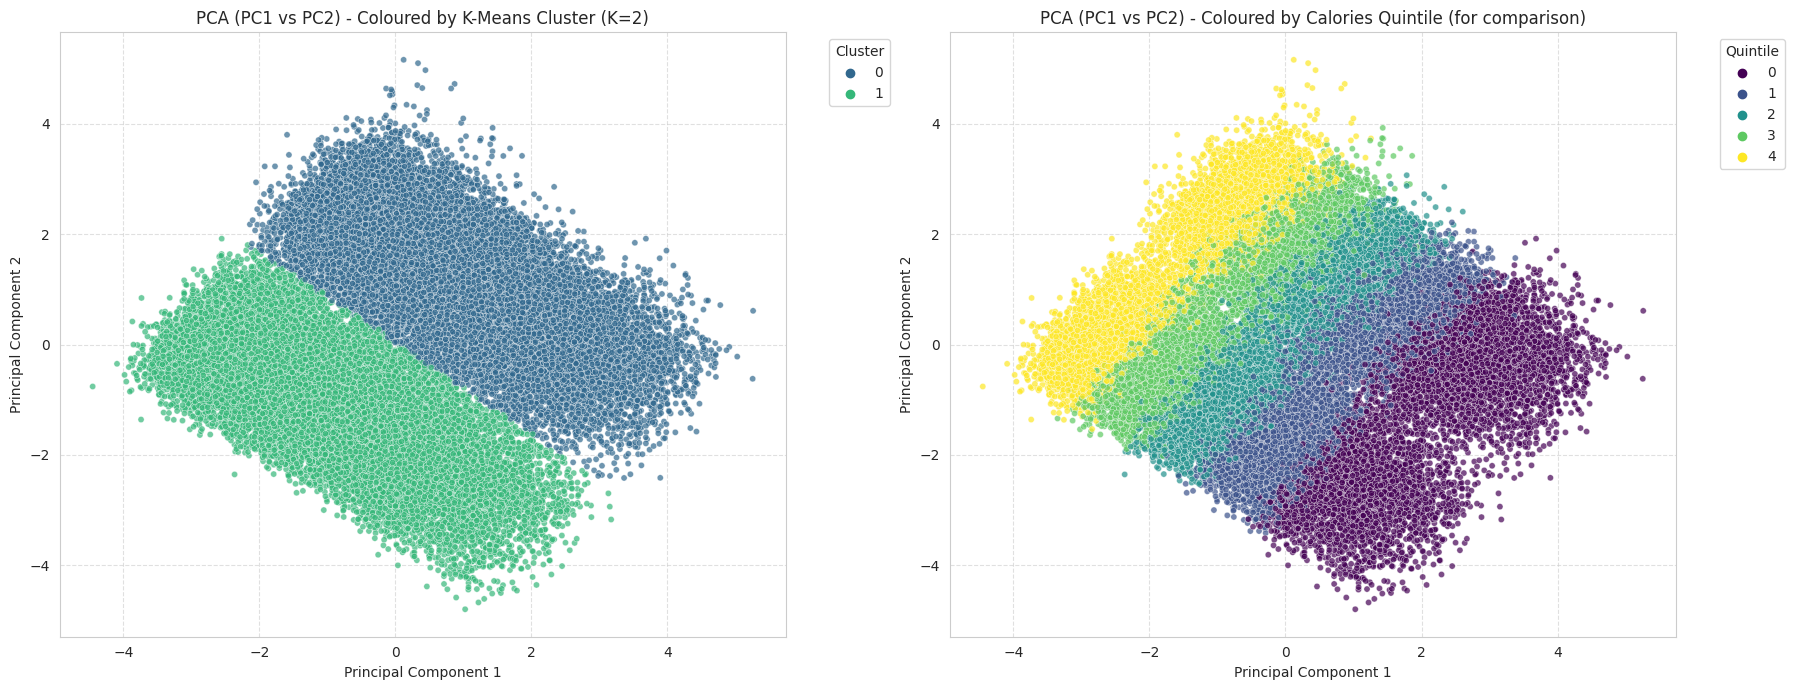

Distribution of the target variable ('Calories') in each K-Means cluster:


,count,mean,std,min,25%,50%,75%,max
0,18402.0,88.232366,66.620466,1.0,31.0,72.0,138.0,300.0
1,19098.0,87.567023,58.033563,1.0,37.0,80.0,133.0,246.0


In [32]:
# Run K-Means clustering (choose K)
# Look at the elbow plot and silhouette score to choose the optimal K.
optimal_k = best_k
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(pca_result[:,0:3])
# clusters = kmeans_model.fit_predict(pca_result)

# Add the clustering results to a DataFrame (for later visualization)
pca_df_for_plotting = pd.DataFrame(data=pca_result, columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3', 'Principal Component 4', 'Principal Component 5'])
pca_df_for_plotting['KMeans_Cluster'] = clusters
pca_df_for_plotting['Target_Quintile'] = target_quintiles.reset_index(drop=True) # インデックスをリセットして結合

# Visualization of clustering results
plt.figure(figsize=(18, 7))

# Plot colored by K-Means cluster
plt.subplot(1, 2, 1)
sns.scatterplot(x='Principal Component 1',
                y='Principal Component 2',
                hue='KMeans_Cluster',
                palette='viridis',
                alpha=0.7,
                s=20,
                data=pca_df_for_plotting)
plt.title(f'PCA (PC1 vs PC2) - Coloured by K-Means Cluster (K={optimal_k})')
plt.xlabel(f'Principal Component 1')
plt.ylabel(f'Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot colored by target quantile (for comparison)
plt.subplot(1, 2, 2)
sns.scatterplot(x='Principal Component 1',
                y='Principal Component 2',
                hue='Target_Quintile',
                palette='viridis',
                alpha=0.7,
                s=20,
                data=pca_df_for_plotting)
plt.title(f'PCA (PC1 vs PC2) - Coloured by {df_train.columns[-1]} Quintile (for comparison)')
plt.xlabel(f'Principal Component 1')
plt.ylabel(f'Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Quintile", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Check the average value of the target variable for each cluster
print("Distribution of the target variable ('Calories') in each K-Means cluster:")
display(df_train_pca_target.groupby(clusters)[df_train.columns[-1]].describe())

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>12 :🔍🧰 Check Libiraries Version</b></div>

In [33]:
!pip install watermark

In [34]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,aeppl,xarray

Last updated: Wed May 28 2025

Python implementation: CPython
Python version       : 3.11.11
IPython version      : 7.34.0

pytensor: 2.27.1
aeppl   : not installed
xarray  : 2025.1.2

missingno  : 0.5.2
matplotlib : 3.7.5
sklearn    : 1.2.2
seaborn    : 0.12.2
numpy      : 1.26.4
pandas     : 2.2.3
statsmodels: 0.14.4

Watermark: 2.5.0

